# 3. ETL tabla 'transactions'

Partiendo de la conexión de Python con la página web de Kaggle a través de la librería 'kagglehub', hemos descargado el archivo 'transactions_data.csv' del conjunto de datos llamado 'Financial Transactions Dataset: Analytics'. Procederemos a limpiarlo, transformarlo, y le haremos un análisis exploratorio.

### Librerías importadas

In [232]:
import kagglehub
import numpy as np
import pandas as pd
from datetime import datetime
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat
from dotenv import load_dotenv

### Constantes

* Directorio actual del script de Python

In [235]:
# Consultamos el directorio actual de trabajo y lo guardamos en la constante 'CURRENT_DIRECTORY'
CURRENT_DIRECTORY=os.getcwd()
CURRENT_DIRECTORY

'C:\\Users\\germa\\Documents\\Python\\edicion_12.0\\Proyecto_integrador\\ETL_finales'

* Directorio de la carpeta 'files'

In [236]:
# Creamos una carpeta llamada 'files' dentro del directorio actual de trabajo
new_folder = 'files'

FILES_DIRECTORY=os.path.join(CURRENT_DIRECTORY, new_folder)

try:
    os.makedirs(FILES_DIRECTORY, exist_ok=True)
    print(f"Carpeta creada en: {FILES_DIRECTORY}")
    
except OSError as e:
    print(f"Error al crear la carpeta: {e}")

Carpeta creada en: C:\Users\germa\Documents\Python\edicion_12.0\Proyecto_integrador\ETL_finales\files


### Funciones creadas

In [237]:
# Establece rangos de tiempo en función de las horas
def categorize_time(time):
    if time >= '00:00' and time < '04:00':
        return 'after midnight'
    elif time >= '04:00' and time < '08:00':
        return 'early morning'
    elif time >= '08:00' and time < '12:00':
        return 'morning'
    elif time >= '12:00' and time < '16:00':
        return 'afternoon'
    elif time >= '16:00' and time < '20:00':
        return 'evening'
    else:
        return 'night'

## Descarga del archivo de datos crudos

In [238]:
# Descargamos en Python el archivo de datos crudos 'transactions_data.csv' del dataset 'Financial Transactions Dataset: Analytics'  
# de la página web de Kaggle
path = kagglehub.dataset_download('computingvictor/transactions-fraud-datasets', path='transactions_data.csv')
print('Archivo csv descargado en:', path)

Archivo csv descargado en: C:\Users\germa\.cache\kagglehub\datasets\computingvictor\transactions-fraud-datasets\versions\1\transactions_data.csv


In [239]:
# Convertimos el archivo descargado en forma de dataframe
df_transactions = pd.read_csv(path)

In [240]:
# Chequeamos el dataframe importado
df_transactions

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,$1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN
13305911,23761869,2019-10-31 23:56:00,1766,2066,$12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN
13305912,23761870,2019-10-31 23:57:00,199,1031,$40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN
13305913,23761873,2019-10-31 23:58:00,1986,5443,$4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN


## Información general del dataframe

In [241]:
# Mostramos las primeras 5 filas del dataframe para visualizar su contenido
df_transactions.head(5)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


El dataframe contiene datos de transacciones financieras (un registro equivale a datos relacionados con una transacción financiera):
* **id**: Es el código identificador de la transacción.
* **date**: Es la fecha (año, mes, día) y hora (hora, minuto, segundo) en que se efectuó la transacción.
* **client_id**: Es el código identificador del cliente que efectuó la transacción.
* **card_id**: Es el código identificador de la tarjeta involucrada en la transacción.
* **amount**: Es el importe de la transacción en moneda de origen (dólar estadounidense).
* **use_chip**: Es el modo en que se efectuó la transacción. Las principales diferencias entre los modos radican en la seguridad y en el método de autenticación, pueden ser: 'Swipe': Se desliza la tarjeta a través de una banda magnética; 'Chip':  Se inserta la tarjeta en el lector. 'Online': No requiere la tarjeta física.
* **merchant_id**: Es el código identificador del comercio involucrado en la transacción.
* **merchant_city**: Es la ciudad en donde se efectuó la transacción. Si la transacción se efectuó en forma remota, figura 'ONLINE'.
* **merchant_state**: Es el país en donde se efectuó la transacción, si el país es 'United States of America' figura el código del estado en forma abreviada. Si la transacción se efectuó en forma remota, figura 'NaN'.
* **zip**: El código postal (ZIP code) de una transacción con tarjeta de débito es el número de código postal asociado a la dirección de residencia que proporcionó el cliente a la entidad bancaria al momento de abrir una cuenta. El código postal (ZIP code) de una transacción con tarjeta de crédito es el código numérico de 5 dígitos asociado a la dirección de residencia que registró el cliente a la entidad bancaria al momento de la emisión de la tarjeta. No es el CVV/CVC (código de seguridad al reverso de la tarjeta), sino que se refiere es la zona postal de residencia del cliente del banco. El código postal (ZIP code) lo solicitan ciertos comercios como medida de seguridad para verificar el titular de la tarjeta, enlazándola con la dirección de residencia registrada del cliente. Se conoce como AVS (Address Verification System). El uso del código postal (Zip Code) '00000' para compras online y en comercios internacionales con tarjetas de USA a veces funciona como un comodín para eludir la verificación de dirección (AVS).
* **mcc**: Merchant Category Code o Código de Categoría de Comerciante: Es el código identificador de cada comercio en función de los tipos de bienes o servicios que ofrecen.
* **errors**: Si la transacción se efectuó de manera exitosa muestra 'NaN'. Si la transacción falló muestra la descripción del error o de los errores, ya que una transacción errónea puede contener más de un error. Los errores pueden ser: Technical Glitch, Bad Expiration, Bad Card Number, Insufficient Balance, Bad Pin, Bad CVV, Bad Zipcode.

In [242]:
# Exploramos la información general del dataframe
df_transactions.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Non-Null Count     Dtype  
---  ------          --------------     -----  
 0   id              13305915 non-null  int64  
 1   date            13305915 non-null  object 
 2   client_id       13305915 non-null  int64  
 3   card_id         13305915 non-null  int64  
 4   amount          13305915 non-null  object 
 5   use_chip        13305915 non-null  object 
 6   merchant_id     13305915 non-null  int64  
 7   merchant_city   13305915 non-null  object 
 8   merchant_state  11742215 non-null  object 
 9   zip             11653209 non-null  float64
 10  mcc             13305915 non-null  int64  
 11  errors          211393 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


Observamos que:
* El dataframe contiene 13.305.915 registros, y 12 columnas.
* Las columnas: 'merchant_state', 'zip', y 'errors' poseen datos nulos.
* Columnas con tipo de dato 'int': 'id', 'client_id', 'card_id', 'merchant_id', 'mcc'.
* Columnas con tipo de dato 'float': 'zip'.
* Columnas con tipo de dato 'str': 'date', 'amount', 'use_chip', 'merchant_city', 'merchant_state', 'errors'.

Antes de comenzar con la limpieza y transformación de datos, haremos una copia del dataframe original, y trabajaremos sobre la copia. De esta forma conservamos los datos originales por si en algún momento necesitamos consultarlos.

In [243]:
transactions = df_transactions.copy()

Nuestro cliente nos ha solicitado que hagamos un análisis de los datos de los últimos 5 años. Por lo tanto, vamos a chequear el período de tiempo que abarca el dataframe:

In [244]:
# Chequeamos el tipo de dato de la columna 'date'
transactions['date'].dtypes

dtype('O')

In [245]:
# Creamos una copia de la columna 'date'
transactions['date_dt'] = transactions['date']

In [246]:
# Cambiamos el tipo de dato de la columna 'date_dt' a datetime
transactions['date_dt'] = pd.to_datetime(transactions['date_dt'])

In [247]:
# Chequeamos el tipo de dato de la columna 'date_dt'
transactions['date_dt'].dtypes

dtype('<M8[ns]')

In [248]:
transactions['date_dt'].min()

Timestamp('2010-01-01 00:01:00')

In [249]:
transactions['date_dt'].max()

Timestamp('2019-10-31 23:59:00')

El dataframe contiene datos desde el 01-01-2010 hasta el 31-10-2019. Vamos a conservar los datos desde el 01-01-2015 para quedarnos con los últimos 5 años. 

In [250]:
transactions = transactions[transactions['date_dt'] >= '2015-01-01']
transactions

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,date_dt
6571667,15471192,2015-01-01 00:01:00,316,2038,$69.55,Chip Transaction,79360,Giddings,TX,78942.0,5411,NaN,2015-01-01 00:01:00
6571668,15471193,2015-01-01 00:01:00,1585,339,$34.82,Swipe Transaction,69972,Jacksonville,FL,32222.0,5814,NaN,2015-01-01 00:01:00
6571669,15471194,2015-01-01 00:03:00,848,3915,$64.40,Chip Transaction,13051,Harwood,MD,20776.0,5813,NaN,2015-01-01 00:03:00
6571670,15471195,2015-01-01 00:04:00,1797,300,$47.93,Chip Transaction,54343,San Leandro,CA,94577.0,4121,NaN,2015-01-01 00:04:00
6571671,15471196,2015-01-01 00:05:00,1557,2471,$25.75,Online Transaction,9932,ONLINE,NaN,NaN,5311,NaN,2015-01-01 00:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,$1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN,2019-10-31 23:56:00
13305911,23761869,2019-10-31 23:56:00,1766,2066,$12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN,2019-10-31 23:56:00
13305912,23761870,2019-10-31 23:57:00,199,1031,$40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN,2019-10-31 23:57:00
13305913,23761873,2019-10-31 23:58:00,1986,5443,$4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN,2019-10-31 23:58:00


In [251]:
# Eliminamos la columna creada 'date_dt'
transactions.drop('date_dt', axis=1, inplace=True)
transactions

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
6571667,15471192,2015-01-01 00:01:00,316,2038,$69.55,Chip Transaction,79360,Giddings,TX,78942.0,5411,NaN
6571668,15471193,2015-01-01 00:01:00,1585,339,$34.82,Swipe Transaction,69972,Jacksonville,FL,32222.0,5814,NaN
6571669,15471194,2015-01-01 00:03:00,848,3915,$64.40,Chip Transaction,13051,Harwood,MD,20776.0,5813,NaN
6571670,15471195,2015-01-01 00:04:00,1797,300,$47.93,Chip Transaction,54343,San Leandro,CA,94577.0,4121,NaN
6571671,15471196,2015-01-01 00:05:00,1557,2471,$25.75,Online Transaction,9932,ONLINE,NaN,NaN,5311,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,$1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN
13305911,23761869,2019-10-31 23:56:00,1766,2066,$12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN
13305912,23761870,2019-10-31 23:57:00,199,1031,$40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN
13305913,23761873,2019-10-31 23:58:00,1986,5443,$4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN


## Limpieza y transformación de datos

### id

* Cambiamos el nombre de la columna para que sea más descriptiva a 'id_transaction'.

In [252]:
transactions.rename(columns ={'id': 'id_transaction'}, inplace=True)

In [253]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='object')

* Validamos si este campo puede ser considerado 'primary key': Para ello controlamos que no hayan registros nulos ni duplicados.

In [254]:
transactions[transactions['id_transaction'].isnull()]

,id_transaction,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors


In [255]:
# Comprobamos que no existen valores nulos.

In [256]:
if len(transactions) == transactions['id_transaction'].nunique():
    print('Comprobamos que no existen valores duplicados.')
else:
    print('Comprobamos que existen valores duplicados. Revisar.')

Comprobamos que no existen valores duplicados.


In [257]:
transactions['id_transaction'].duplicated().value_counts()

id_transaction
False    6734248
Name: count, dtype: int64

In [258]:
# Comprobamos que no existen valores duplicados ya que la totalidad de los registros arrojan 'False'.

In [259]:
# Concluimos que este campo puede ser utilizado como 'primary key'.

### date

* Este campo contiene información sobre la fecha (año, mes, día) y hora (hora, minuto, segundo) en que se efectuó la transacción. Separamos esta información sobre fecha (año, mes, día) y hora (hora, minuto) en 2 columnas llamadas 'date_tx' y 'time_tx', respectivamente, para optimizar el modelo de datos.
* Decidimos que la hora se muestre en horas y minutos (y eliminamos los segundos) ya que esta granularidad resulta suficiente para los objetivos del proyecto planteado (entender el perfil y los patrones de gasto de los clientes, gestionar el riesgo financiero, diseñar estrategias de crecimiento). De esta manera no sobrecargamos con información innesaria al modelo de datos. Si con esta información se quiere detectar fraude en un futuro los segundos resultan de vital importancia, y en ese caso habrá que modificar la granularidad de esta columna.

In [260]:
# Creamos la columna 'time_tx' para que solo muestre la hora (hora, minuto)
transactions['time_tx'] = transactions['date'].str[11:]
transactions['time_tx'] = transactions['time_tx'].str[:5]
transactions['time_tx']

6571667     00:01
6571668     00:01
6571669     00:03
6571670     00:04
6571671     00:05
            ...  
13305910    23:56
13305911    23:56
13305912    23:57
13305913    23:58
13305914    23:59
Name: time_tx, Length: 6734248, dtype: object

In [261]:
# Reemplazamos la columna 'date' para que solo muestre la fecha (año, mes, día)
transactions['date'] = transactions['date'].str[:10]
transactions['date']

6571667     2015-01-01
6571668     2015-01-01
6571669     2015-01-01
6571670     2015-01-01
6571671     2015-01-01
               ...    
13305910    2019-10-31
13305911    2019-10-31
13305912    2019-10-31
13305913    2019-10-31
13305914    2019-10-31
Name: date, Length: 6734248, dtype: object

In [262]:
# Renombramos la columna 'date' a 'date_tx'
transactions.rename(columns ={'date': 'date_tx'}, inplace=True)

In [263]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount',
       'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip',
       'mcc', 'errors', 'time_tx'],
      dtype='object')

* Cambiamos el tipo de dato de la columna 'date_tx' a 'datetime'. La columna 'time_tx' la dejamos con tipo de dato 'str' ya que si la convertimos en 'datetime' nos muestra un formato no deseado: '%Y-%m-%d %H:%M:%S'. Cabe aclarar que la columna 'time_tx' con tipo de dato 'str' no afecta el análisis.

In [264]:
# Cambiamos el tipo de dato de la columna 'date_tx' a 'datetime'
transactions['date_tx'] = pd.to_datetime(transactions['date_tx'])

In [265]:
# Chequeamos de tipo de dato 'datetime' de columna 'date_tx'
transactions['date_tx'].dtypes

dtype('<M8[ns]')

In [266]:
# Chequeamos la columna 'date_tx' en el dataframe
transactions['date_tx']

6571667    2015-01-01
6571668    2015-01-01
6571669    2015-01-01
6571670    2015-01-01
6571671    2015-01-01
              ...    
13305910   2019-10-31
13305911   2019-10-31
13305912   2019-10-31
13305913   2019-10-31
13305914   2019-10-31
Name: date_tx, Length: 6734248, dtype: datetime64[ns]

* Creamos las columnas 'calendar_id' y 'time_id' para relacionar en forma optimizada esta tabla con las tablas 'calendar' y 'time' que crearemos en Power BI para las visualizaciones.

In [267]:
# Columna 'calendar_id': Formato '%Y-%m-%d' convertido a tipo de dato 'int'
transactions['calendar_id'] = transactions['date_tx'].dt.strftime('%Y%m%d').astype(int)
transactions['calendar_id']

6571667     20150101
6571668     20150101
6571669     20150101
6571670     20150101
6571671     20150101
              ...   
13305910    20191031
13305911    20191031
13305912    20191031
13305913    20191031
13305914    20191031
Name: calendar_id, Length: 6734248, dtype: int64

In [268]:
# Columna 'time_id': Formato '%H:%M' convertido a formato '%H%M' con tipo de dato 'str'
transactions['time_id'] = transactions['time_tx'].str.replace(':','')
transactions['time_id']

6571667     0001
6571668     0001
6571669     0003
6571670     0004
6571671     0005
            ... 
13305910    2356
13305911    2356
13305912    2357
13305913    2358
13305914    2359
Name: time_id, Length: 6734248, dtype: object

### client_id

* Se conserva la columna tal cual se encuentra.

### card_id

* Se conserva la columna tal cual se encuentra.

### amount

* Cambiamos el nombre de la columna para que sea más descriptiva a 'amount_usd'.

In [269]:
transactions.rename(columns ={'amount': 'amount_usd'}, inplace=True)

In [270]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount_usd',
       'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip',
       'mcc', 'errors', 'time_tx', 'calendar_id', 'time_id'],
      dtype='object')

* Quitamos el signo '$' que acompaña a cada registro para luego poder transformar el tipo de dato a 'float'.

In [271]:
transactions['amount_usd'] = transactions['amount_usd'].str.replace('$','')
transactions['amount_usd']

6571667     69.55
6571668     34.82
6571669     64.40
6571670     47.93
6571671     25.75
            ...  
13305910     1.11
13305911    12.80
13305912    40.44
13305913     4.00
13305914    12.88
Name: amount_usd, Length: 6734248, dtype: object

In [272]:
# Cambiamos el tipo de dato a 'float'
transactions['amount_usd'] = pd.to_numeric(transactions['amount_usd'], errors='coerce')
transactions['amount_usd']

6571667     69.55
6571668     34.82
6571669     64.40
6571670     47.93
6571671     25.75
            ...  
13305910     1.11
13305911    12.80
13305912    40.44
13305913     4.00
13305914    12.88
Name: amount_usd, Length: 6734248, dtype: float64

In [273]:
# Comprobamos que no existen valores nulos luego de haber quitado el signo '$' de cada registro
transactions[transactions['amount_usd'].isnull()]

,id_transaction,date_tx,client_id,card_id,amount_usd,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id


### use_chip

* Cambiamos el nombre de la columna para que sea más descriptiva a 'transaction_type'.

In [274]:
transactions.rename(columns ={'use_chip': 'transaction_type'}, inplace=True)

In [275]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount_usd',
       'transaction_type', 'merchant_id', 'merchant_city', 'merchant_state',
       'zip', 'mcc', 'errors', 'time_tx', 'calendar_id', 'time_id'],
      dtype='object')

* Las categorías que componen esta columna y la cantidad de registros que contiene cada una son:

In [276]:
transactions['transaction_type'].value_counts()

transaction_type
Chip Transaction      4780818
Swipe Transaction     1135806
Online Transaction     817624
Name: count, dtype: int64

* Eliminamos la palabra 'Transaction' ya que figura en todos los registros ya que no agrega valor. Además eliminamos los espacios en blanco al inicio y al final de cada registro, y convertimos todo el texto a minúsculas.

In [278]:
transactions['transaction_type'] = transactions['transaction_type'].str.replace('Transaction', '').str.strip().str.lower()
transactions['transaction_type'].value_counts()

transaction_type
chip      4780818
swipe     1135806
online     817624
Name: count, dtype: int64

* Creamos una nueva columna llamada 'transaction_type_id' para codificar con valores numéricos que empiezan en 1 los 'transaction_type' en orden ascendente.

In [279]:
transactions['transaction_type_id'] = pd.factorize(transactions['transaction_type'], sort=True)[0] + 1
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,transaction_type,merchant_id,merchant_city,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id
13198051,23628696,2019-10-03,1855,5967,94.80,swipe,81536,San Jose,CA,95121.0,5310,NaN,14:56,20191003,1456,3
10787235,20649310,2018-01-10,1859,2703,5.47,swipe,64908,Middletown,NY,10940.0,5812,NaN,11:52,20180110,1152,3
11045001,20966299,2018-03-18,1098,4626,-74.00,chip,59935,Granville,IA,51022.0,5499,NaN,16:37,20180318,1637,1
6753066,15694068,2015-02-18,744,4158,14.26,chip,27506,Miami,FL,33196.0,5310,NaN,08:43,20150218,0843,1
8182590,17446552,2016-02-28,528,3834,73.00,chip,26810,Le Mars,IA,51031.0,5541,NaN,13:26,20160228,1326,1


* Creamos una tabla llamada 'transaction_type' a partir de la tabla 'transactions', para separar en el modelo de datos las 'transaction_type' de las 'transactions'. 

In [280]:
transaction_type = transactions[['transaction_type_id', 'transaction_type']].drop_duplicates()
transaction_type

,transaction_type_id,transaction_type
6571667,1,chip
6571668,3,swipe
6571671,2,online


In [281]:
# Renombramos las columnas de la nueva tabla 'transaction_type' para que la nomenclatura del id esté alineada a las primary key, 
# y para que las columnas sean más descriptivas.
transaction_type.rename(columns={'transaction_type_id':'id_transaction_type'}, inplace=True)
transaction_type

,id_transaction_type,transaction_type
6571667,1,chip
6571668,3,swipe
6571671,2,online


In [282]:
# Ordenamos de forma ascendente la columna 'id_transaction_type'
transaction_type.sort_values('id_transaction_type', inplace=True)
transaction_type

,id_transaction_type,transaction_type
6571667,1,chip
6571671,2,online
6571668,3,swipe


In [283]:
# Reseteamos el índice para que el mismo empiece en 0
transaction_type.reset_index(drop=True, inplace=True)
transaction_type

,id_transaction_type,transaction_type
0,1,chip
1,2,online
2,3,swipe


In [284]:
# Exploramos la información general de la nueva tabla
transaction_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id_transaction_type  3 non-null      int64 
 1   transaction_type     3 non-null      object
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


* Luego de crear la tabla 'transaction_type', procedemos a eliminar la columna 'transaction_type' de la tabla 'transactions', para no repetir información en el modelo de datos. 

In [285]:
transactions.drop('transaction_type', axis=1, inplace=True)
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,merchant_city,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id
8184164,17448472,2016-02-28,194,5062,36.27,22204,Fountain City,IN,47341.0,5541,NaN,22:15,20160228,2215,1
8226155,17499972,2016-03-12,257,104,-268.00,44795,Sycamore,IL,60178.0,3780,NaN,00:43,20160312,0043,3
11379622,21379376,2018-06-14,1638,4296,19.59,22204,Guadalajara,Mexico,NaN,5541,NaN,12:29,20180614,1229,1
7481186,16586093,2015-08-28,852,90,63.00,26810,Chiefland,FL,32644.0,5541,NaN,17:09,20150828,1709,1
11458624,21477065,2018-07-05,1104,4849,-85.00,61195,Pompano Beach,FL,33060.0,5541,NaN,07:27,20180705,0727,1


### merchant_id

* Se conserva la columna tal cual se encuentra.

### merchant_city

* Cambiamos el nombre de la columna a 'city' para que este campo pueda ser utilizado en toda la base de datos, no sólo para referirnos a la ciudad en donde está ubicado un comercio.

In [286]:
transactions.rename(columns ={'merchant_city': 'city'}, inplace=True)

In [287]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount_usd',
       'merchant_id', 'city', 'merchant_state', 'zip', 'mcc', 'errors',
       'time_tx', 'calendar_id', 'time_id', 'transaction_type_id'],
      dtype='object')

* Las ciudades que componen esta columna son:

In [288]:
sorted(transactions['city'].unique())

['Abbeville',
 'Abbotsford',
 'Abbott',
 'Abbottstown',
 'Aberdeen',
 'Abernathy',
 'Abilene',
 'Abingdon',
 'Abington',
 'Abiquiu',
 'Abita Springs',
 'Abrams',
 'Absarokee',
 'Absecon',
 'Abu Dhabi',
 'Abuja',
 'Acampo',
 'Acapulco',
 'Accident',
 'Accokeek',
 'Accord',
 'Accra',
 'Ackerly',
 'Ackley',
 'Ackworth',
 'Acra',
 'Acton',
 'Acushnet',
 'Acworth',
 'Ada',
 'Adah',
 'Adairsville',
 'Adairville',
 'Adams',
 'Adams Center',
 'Adams Run',
 'Adamsburg',
 'Adamstown',
 'Adamsville',
 'Addis',
 'Addison',
 'Addy',
 'Adel',
 'Adelanto',
 'Adell',
 'Adena',
 'Adger',
 'Adkins',
 'Adrian',
 'Advance',
 'Afton',
 'Agawam',
 'Agency',
 'Agoura Hills',
 'Agra',
 'Agua Dulce',
 'Aguanga',
 'Aguilar',
 'Ahoskie',
 'Ahwahnee',
 'Aiea',
 'Aiken',
 'Ailey',
 'Ainsworth',
 'Airville',
 'Airway Heights',
 'Aitkin',
 'Ajo',
 'Akron',
 'Alabaster',
 'Alachua',
 'Alameda',
 'Alamo',
 'Alamogordo',
 'Alamosa',
 'Alanson',
 'Alba',
 'Albany',
 'Albemarle',
 'Albert Lea',
 'Alberta',
 'Alberton',
 

* La cantidad de ciudades diferentes que contiene esta columna es:

In [289]:
transactions['city'].nunique()

11119

* Para homogeneizar el texto de todos los registros de esta columna eliminamos los espacios en blanco al inicio y al final de cada registro, y convertimos todo el texto a formato de nombre propio (title).

In [290]:
transactions['city'] = transactions['city'].str.strip().str.title()
transactions['city'].sample(5)

10298238        El Paso
10808821    Bakersfield
12237633       Rochelle
11001792        Wagoner
10266727         Monsey
Name: city, dtype: object

In [291]:
# Luego de homogeneizar el texto, corroboramos si la cantidad de ciudades diferentes cambió o no
transactions['city'].nunique()

11119

In [292]:
# Sigue siendo la misma cantidad de ciudaddes diferentes

* Modificamos el registro 'Online' para que quede al principio de la tabla nueva que crearemos a continuación. Para ello lo renombramos como '0_online'.

In [293]:
transactions['city'] = transactions['city'].str.replace('Online','0_online')
transactions['city']

6571667         Giddings
6571668     Jacksonville
6571669          Harwood
6571670      San Leandro
6571671         0_online
                ...     
13305910     West Covina
13305911        0_online
13305912           Allen
13305913       Daly City
13305914      Greenbrier
Name: city, Length: 6734248, dtype: object

* Creamos una nueva columna llamada 'city_id' para codificar con valores numéricos que empiezan en 1 las 'city' en orden ascendente.

In [294]:
transactions['city_id'] = pd.factorize(transactions['city'], sort=True)[0] + 1
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,city,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id
8239465,17516373,2016-03-15,331,3818,91.92,17976,0_online,NaN,NaN,4900,NaN,12:55,20160315,1255,2,1
12328076,22552064,2019-02-17,1302,5464,57.46,50867,Jefferson,NC,28640.0,5541,NaN,15:49,20190217,1549,3,4783
7010556,16009575,2015-04-27,803,1172,26.77,85247,0_online,NaN,NaN,5815,NaN,09:58,20150427,0958,2,1
12697367,23009833,2019-05-25,1144,2223,58.27,18215,Houston,TX,77099.0,5719,NaN,18:18,20190525,1818,1,4545
7442701,16538963,2015-08-18,1797,299,42.31,54343,San Leandro,CA,94577.0,4121,NaN,14:27,20150818,1427,1,8774


* Creamos una tabla llamada 'city' a partir de la tabla 'transactions', para separar en el modelo de datos las 'city' de las 'transactions'. 

In [295]:
city = transactions[['city_id', 'city']].drop_duplicates()
city

,city_id,city
6571667,3670,Giddings
6571668,4753,Jacksonville
6571669,4187,Harwood
6571670,8774,San Leandro
6571671,1,0_online
...,...,...
13275268,8949,Seabeck
13285412,3762,Globe
13301715,1717,Chester Heights
13304512,9057,Shawboro


In [296]:
# Renombramos las columnas de la nueva tabla 'city' para que la nomenclatura del id esté alineada a las primary key, 
# y para que las columnas sean más descriptivas.
city.rename(columns={'city_id':'id_city'}, inplace=True)
city

,id_city,city
6571667,3670,Giddings
6571668,4753,Jacksonville
6571669,4187,Harwood
6571670,8774,San Leandro
6571671,1,0_online
...,...,...
13275268,8949,Seabeck
13285412,3762,Globe
13301715,1717,Chester Heights
13304512,9057,Shawboro


In [297]:
# Ordenamos de forma ascendente la columna 'id_city'
city.sort_values('id_city', inplace=True)
city

,id_city,city
6571671,1,0_online
6572493,2,Abbeville
7016973,3,Abbotsford
12975936,4,Abbott
10458645,5,Abbottstown
...,...,...
7824625,11115,Zumbrota
6576966,11116,Zuni
7826995,11117,Zurich
11261151,11118,Zwingle


In [298]:
# Reseteamos el índice para que el mismo empiece en 0
city.reset_index(drop=True, inplace=True)
city

,id_city,city
0,1,0_online
1,2,Abbeville
2,3,Abbotsford
3,4,Abbott
4,5,Abbottstown
...,...,...
11114,11115,Zumbrota
11115,11116,Zuni
11116,11117,Zurich
11117,11118,Zwingle


In [299]:
# Exploramos la información general de la nueva tabla
city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11119 entries, 0 to 11118
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id_city  11119 non-null  int64 
 1   city     11119 non-null  object
dtypes: int64(1), object(1)
memory usage: 173.9+ KB


* Luego de crear la tabla 'city', procedemos a eliminar la columna 'city' de la tabla 'transactions' para no repetir información en el modelo de datos.

In [300]:
transactions.drop('city', axis=1, inplace=True)
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id
7004271,16001867,2015-04-25,988,4384,90.22,76589,LA,70056.0,7538,NaN,15:44,20150425,1544,1,3963
8865396,18284501,2016-08-26,267,4411,49.90,75781,KY,40337.0,5411,NaN,13:46,20160826,1346,1,4787
12239055,22441645,2019-01-25,973,3833,11.43,92883,MS,38620.0,5812,NaN,11:04,20190125,1104,1,2160
12475019,22734537,2019-03-28,1815,2035,249.38,64127,RI,2903.0,1711,NaN,11:16,20190328,1116,1,8081
8339597,17639221,2016-04-10,42,2824,28.23,75936,GA,31601.0,5814,NaN,22:59,20160410,2259,1,10190


### merchant_state

* Los países y estados del país 'United States of America' (estos últimos aparecen en forma abreviada) que componen esta columna son:

In [301]:
transactions['merchant_state'].unique()

array(['TX', 'FL', 'MD', 'CA', nan, 'OH', 'NV', 'LA', 'MT', 'MI', 'IL',
       'NC', 'KY', 'NY', 'CO', 'AZ', 'NJ', 'WA', 'ID', 'ND', 'AR', 'WI',
       'CT', 'GA', 'AL', 'TN', 'OR', 'MA', 'SD', 'KS', 'PA', 'NE', 'IN',
       'HI', 'RI', 'MN', 'MO', 'VA', 'OK', 'MS', 'SC', 'WV', 'DE', 'IA',
       'NM', 'Philippines', 'UT', 'ME', 'Mexico', 'NH', 'WY', 'VT',
       'Canada', 'China', 'AK', 'Jamaica', 'DC', 'United Kingdom',
       'Hong Kong', 'South Korea', 'Thailand', 'Taiwan', 'Aruba',
       'France', 'United Arab Emirates', 'Egypt', 'Portugal', 'Ireland',
       'Japan', 'Hungary', 'India', 'Spain', 'Cyprus', 'Denmark',
       'Dominican Republic', 'Poland', 'Czech Republic', 'Pakistan',
       'Germany', 'Italy', 'Colombia', 'Croatia', 'Norway', 'Belgium',
       'Switzerland', 'Ecuador', 'The Bahamas', 'Argentina', 'Indonesia',
       'Peru', 'Bangladesh', 'Senegal', 'Nigeria', 'Netherlands',
       'Romania', 'Australia', 'Chile', 'South Africa', 'Austria',
       'Latvia', 'Gabo

* La cantidad de países diferentes que contiene esta columna es:

In [302]:
transactions['merchant_state'].nunique()

163

* Vamos a crear una columna aparte llamada 'state_usa' para tener la información de las abreviaturas de estados del país 'United States of America' aparte, y en la columna 'merchant_state' vamos a reemplazar esos valores por 'United States of America'. De esta manera en la columna 'merchant_state' tendremos la información de países únicamente. Luego la columna 'merchant_state' la renombraremos a 'country' para que este campo pueda ser utilizado en toda la base de datos, no sólo para referirnos al país en donde está ubicado un comercio.

In [303]:
# Creamos la columna 'state_usa' a partir de la columna 'merchant_state'
transactions['state_usa'] = transactions['merchant_state']

In [304]:
# Corroboramos la creación de la nueva columna 'state_usa'
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,state_usa
7634648,16774133,2015-10-07,1775,344,-84.00,59935,DE,19963.0,5499,NaN,21:11,20151007,2111,1,6280,DE
10194124,19918950,2017-08-08,275,3911,73.31,60569,TX,77587.0,5300,NaN,16:25,20170808,1625,1,9343,TX
10569444,20381170,2017-11-14,124,2725,2.82,25887,OK,73505.0,5814,NaN,15:28,20171114,1528,3,5369,OK
8909924,18339225,2016-09-07,1295,5017,14.53,35451,MN,55901.0,5812,NaN,08:45,20160907,0845,1,8434,MN
7221093,16267894,2015-06-21,1096,5225,5.91,68765,NY,13212.0,5411,NaN,16:03,20150621,1603,1,9744,NY


In [305]:
# En la columna 'state_usa' eliminamos la información de los países
transactions['state_usa'] = transactions['state_usa'].apply(lambda x: None if len(str(x)) > 2 else x)

In [306]:
# Los valores únicos de la columna 'state_usa' ahora son
transactions['state_usa'].unique()

array(['TX', 'FL', 'MD', 'CA', None, 'OH', 'NV', 'LA', 'MT', 'MI', 'IL',
       'NC', 'KY', 'NY', 'CO', 'AZ', 'NJ', 'WA', 'ID', 'ND', 'AR', 'WI',
       'CT', 'GA', 'AL', 'TN', 'OR', 'MA', 'SD', 'KS', 'PA', 'NE', 'IN',
       'HI', 'RI', 'MN', 'MO', 'VA', 'OK', 'MS', 'SC', 'WV', 'DE', 'IA',
       'NM', 'UT', 'ME', 'NH', 'WY', 'VT', 'AK', 'DC'], dtype=object)

* Los **valores nulos** de la columna 'state_usa' se refieren a que esos registros NO son estados del país 'United States of America'. Los vamos a rellenar con '0_out_USA' para que quede al principio de la tabla nueva que crearemos luego.

In [307]:
transactions.fillna({'state_usa': '0_out_USA'}, inplace=True)

In [308]:
# Los valores únicos de la columna 'state_usa' ahora son
transactions['state_usa'].unique()

array(['TX', 'FL', 'MD', 'CA', '0_out_USA', 'OH', 'NV', 'LA', 'MT', 'MI',
       'IL', 'NC', 'KY', 'NY', 'CO', 'AZ', 'NJ', 'WA', 'ID', 'ND', 'AR',
       'WI', 'CT', 'GA', 'AL', 'TN', 'OR', 'MA', 'SD', 'KS', 'PA', 'NE',
       'IN', 'HI', 'RI', 'MN', 'MO', 'VA', 'OK', 'MS', 'SC', 'WV', 'DE',
       'IA', 'NM', 'UT', 'ME', 'NH', 'WY', 'VT', 'AK', 'DC'], dtype=object)

In [309]:
# En la columna 'merchant_state' reemplazamos los valores de las abreviaturas de los estados del país 'United States of America' por 
# 'United States of America'
transactions['merchant_state'] = transactions['merchant_state'].apply(lambda x: 'United States of America' if len(str(x)) == 2 else x)

In [310]:
# Los valores únicos de la columna 'merchant_state' ahora son
transactions['merchant_state'].unique()

array(['United States of America', nan, 'Philippines', 'Mexico', 'Canada',
       'China', 'Jamaica', 'United Kingdom', 'Hong Kong', 'South Korea',
       'Thailand', 'Taiwan', 'Aruba', 'France', 'United Arab Emirates',
       'Egypt', 'Portugal', 'Ireland', 'Japan', 'Hungary', 'India',
       'Spain', 'Cyprus', 'Denmark', 'Dominican Republic', 'Poland',
       'Czech Republic', 'Pakistan', 'Germany', 'Italy', 'Colombia',
       'Croatia', 'Norway', 'Belgium', 'Switzerland', 'Ecuador',
       'The Bahamas', 'Argentina', 'Indonesia', 'Peru', 'Bangladesh',
       'Senegal', 'Nigeria', 'Netherlands', 'Romania', 'Australia',
       'Chile', 'South Africa', 'Austria', 'Latvia', 'Gabon', 'Brazil',
       'Serbia', 'Singapore', 'Greece', 'Sweden', 'Vatican City',
       'Slovenia', 'Costa Rica', 'Finland', 'Israel', 'Tunisia',
       'Saudi Arabia', 'Bahrain', 'Russia', 'Sierra Leone', 'Kosovo',
       'Ukraine', 'Kyrgyzstan', 'Malaysia', 'Barbados', 'Macedonia',
       'Lithuania', 'Luxembou

* Investigamos los **valores nulos** de la columna 'merchant_state'.

In [311]:
transactions[transactions['merchant_state'].isna()]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,state_usa
6571671,15471196,2015-01-01,1557,2471,25.75,9932,NaN,NaN,5311,NaN,00:05,20150101,0005,2,1,0_out_USA
6571672,15471197,2015-01-01,1684,94,28.63,39021,NaN,NaN,4784,NaN,00:06,20150101,0006,2,1,0_out_USA
6571677,15471202,2015-01-01,335,5131,318.05,50292,NaN,NaN,7801,NaN,00:14,20150101,0014,2,1,0_out_USA
6571678,15471203,2015-01-01,1772,2283,28.43,15143,NaN,NaN,4784,NaN,00:15,20150101,0015,2,1,0_out_USA
6571682,15471208,2015-01-01,1560,5455,9.74,9932,NaN,NaN,5311,NaN,00:21,20150101,0021,2,1,0_out_USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305879,23761832,2019-10-31,1556,2972,17.65,88459,NaN,NaN,5311,NaN,23:22,20191031,2322,2,1,0_out_USA
13305880,23761833,2019-10-31,1797,5660,34.81,15143,NaN,NaN,4784,NaN,23:22,20191031,2322,2,1,0_out_USA
13305888,23761843,2019-10-31,1069,5167,59.71,39021,NaN,NaN,4784,NaN,23:33,20191031,2333,2,1,0_out_USA
13305897,23761853,2019-10-31,1422,5696,694.30,70268,NaN,NaN,4722,NaN,23:39,20191031,2339,2,1,0_out_USA


In [312]:
# Contamos la cantidad de registros que poseen valores nulos en la columna 'merchant_state' filtrado por la columna 'city_id'
transactions[transactions['merchant_state'].isna()]['city_id'].value_counts()

city_id
1    823412
Name: count, dtype: int64

In [313]:
# Contamos la cantidad de registros que poseen valores nulos en la columna 'merchant_state' y que en la columna 'city_id' el
# código no sea igual a 1 (1 significa 'online')
transactions[(transactions['merchant_state'].isna()) & (transactions['city_id'] != 1)]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,merchant_state,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,state_usa


In [314]:
# Concluimos que los valores nulos corresponden a transacciones hechas en forma 'online', por lo tanto vamos a rellenar los valores 
# nulos para que queden al principio de la tabla nueva que crearemos a continuación. Los rellenaremos con '0_online', igual denominación 
# que figura en la tabla 'city.'
transactions.fillna({'merchant_state': '0_online'}, inplace=True)

In [315]:
# Los valores únicos de la columna 'merchant_state' ahora son
transactions['merchant_state'].unique()

array(['United States of America', '0_online', 'Philippines', 'Mexico',
       'Canada', 'China', 'Jamaica', 'United Kingdom', 'Hong Kong',
       'South Korea', 'Thailand', 'Taiwan', 'Aruba', 'France',
       'United Arab Emirates', 'Egypt', 'Portugal', 'Ireland', 'Japan',
       'Hungary', 'India', 'Spain', 'Cyprus', 'Denmark',
       'Dominican Republic', 'Poland', 'Czech Republic', 'Pakistan',
       'Germany', 'Italy', 'Colombia', 'Croatia', 'Norway', 'Belgium',
       'Switzerland', 'Ecuador', 'The Bahamas', 'Argentina', 'Indonesia',
       'Peru', 'Bangladesh', 'Senegal', 'Nigeria', 'Netherlands',
       'Romania', 'Australia', 'Chile', 'South Africa', 'Austria',
       'Latvia', 'Gabon', 'Brazil', 'Serbia', 'Singapore', 'Greece',
       'Sweden', 'Vatican City', 'Slovenia', 'Costa Rica', 'Finland',
       'Israel', 'Tunisia', 'Saudi Arabia', 'Bahrain', 'Russia',
       'Sierra Leone', 'Kosovo', 'Ukraine', 'Kyrgyzstan', 'Malaysia',
       'Barbados', 'Macedonia', 'Lithuania', 'L

* Como la columna 'merchant_state' se refiere a países, le cambiaremos el nombre a 'country' para que este campo pueda ser utilizado en toda la base de datos, no sólo para referirnos al país en donde está ubicado un comercio.

In [316]:
transactions.rename(columns={'merchant_state':'country'}, inplace=True)

In [317]:
# Corroboramos el cambio de nombre de la columna
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount_usd',
       'merchant_id', 'country', 'zip', 'mcc', 'errors', 'time_tx',
       'calendar_id', 'time_id', 'transaction_type_id', 'city_id',
       'state_usa'],
      dtype='object')

* Creamos una nueva columna llamada 'country_id' para codificar con valores numéricos que empiezan en 1 los 'country' en orden ascendente.

In [318]:
transactions['country_id'] = pd.factorize(transactions['country'], sort=True)[0] + 1
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,country,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,state_usa,country_id
8616482,17979257,2016-06-22,1256,236,28.16,50783,United States of America,6614.0,5411,NaN,12:06,20160622,1206,1,9598,CT,110
8993875,18442264,2016-09-29,1808,4702,26.41,41122,0_online,NaN,4784,NaN,09:08,20160929,0908,2,1,0_out_USA,1
9603123,19190437,2017-03-07,451,5810,48.00,32175,United States of America,68111.0,7538,NaN,15:24,20170307,1524,1,7258,NE,110
9124224,18602336,2016-11-02,803,1172,5.11,50867,United States of America,95382.0,5541,NaN,12:12,20161102,1212,1,10086,CA,110
12873205,23227184,2019-07-10,11,243,50.26,13915,United States of America,21136.0,5812,NaN,17:18,20190710,1718,1,8274,MD,110


* Creamos una tabla llamada 'country' a partir de la tabla 'transactions', para separar en el modelo de datos los 'country' de las 'transactions'.

In [319]:
country = transactions[['country_id', 'country']].drop_duplicates()
country

,country_id,country
6571667,110,United States of America
6571671,1,0_online
6572343,79,Philippines
6572999,65,Mexico
6573870,15,Canada
...,...,...
12311065,104,Trinidad and Tobago
12778987,82,Republic of the Congo
12834842,14,Burkina Faso
13002737,7,Azerbaijan


In [320]:
# Renombramos las columnas de la nueva tabla 'country' para que la nomenclatura del id esté alineada a las primary key, 
# y para que las columnas sean más descriptivas.
country.rename(columns={'country_id':'id_country'}, inplace=True)
country

,id_country,country
6571667,110,United States of America
6571671,1,0_online
6572343,79,Philippines
6572999,65,Mexico
6573870,15,Canada
...,...,...
12311065,104,Trinidad and Tobago
12778987,82,Republic of the Congo
12834842,14,Burkina Faso
13002737,7,Azerbaijan


In [321]:
# Ordenamos de forma ascendente la columna 'id_country'
country.sort_values('id_country', inplace=True)
country

,id_country,country
6571671,1,0_online
10977586,2,Albania
6887220,3,Argentina
6599163,4,Aruba
7004781,5,Australia
...,...,...
6571667,110,United States of America
8895344,111,Vanuatu
7288069,112,Vatican City
11981446,113,Venezuela


In [322]:
# Reseteamos el índice para que el mismo empiece en 0
country.reset_index(drop=True, inplace=True)
country

,id_country,country
0,1,0_online
1,2,Albania
2,3,Argentina
3,4,Aruba
4,5,Australia
...,...,...
109,110,United States of America
110,111,Vanuatu
111,112,Vatican City
112,113,Venezuela


In [323]:
# Exploramos la información general de la nueva tabla
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_country  114 non-null    int64 
 1   country     114 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.9+ KB


* Luego de crear la tabla 'country', procedemos a eliminar la columna 'country' de la tabla 'transactions', para no repetir información en el modelo de datos.

In [324]:
transactions.drop('country', axis=1, inplace=True)
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,state_usa,country_id
12091355,22258962,2018-12-17,1551,2537,40.05,96246,NaN,4784,NaN,16:15,20181217,1615,2,1,0_out_USA,1
12342300,22569661,2019-02-21,1288,2428,11.51,36257,25159.0,5411,NaN,13:21,20190221,1321,1,7876,WV,110
8586300,17942108,2016-06-14,951,2628,15.61,18563,NaN,4121,NaN,13:44,20160614,1344,2,1,0_out_USA,1
8131871,17384251,2016-02-15,451,5810,42.18,18131,75043.0,4111,NaN,09:31,20160215,0931,1,3603,TX,110
8122850,17373156,2016-02-12,1888,1017,81.00,43293,98188.0,5499,NaN,20:35,20160212,2035,1,8967,WA,110


* Creamos una nueva columna llamada 'state_usa_id' para codificar con valores numéricos que empiezan en 1 los 'state_usa' en orden ascendente.

In [325]:
transactions['state_usa_id'] = pd.factorize(transactions['state_usa'], sort=True)[0] + 1
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,state_usa,country_id,state_usa_id
7660690,16806023,2015-10-14,346,3379,56.20,26909,93221.0,5211,NaN,16:15,20151014,1615,3,3145,CA,110,6
12996977,23380145,2019-08-11,1569,4109,25.79,58040,32583.0,7832,NaN,18:29,20190811,1829,3,6321,FL,110,11
11518150,21550450,2018-07-20,972,4166,-50.00,22204,79912.0,5541,NaN,13:37,20180720,1337,3,2907,TX,110,45
8081647,17322520,2016-02-02,1451,250,73.69,50867,2151.0,5541,NaN,04:44,20160202,0444,1,8294,MA,110,21
11100193,21034415,2018-04-02,147,2634,1.03,61195,36117.0,5541,NaN,08:34,20180402,0834,1,6441,AL,110,3


* Creamos una tabla llamada 'state_usa' a partir de la tabla 'transactions', para separar en el modelo de datos los 'state_usa' de las 'transactions' y para que este campo pueda ser utilizado en toda la base de datos, no sólo para referirnos al estado de USA en donde está ubicado un comercio.

In [326]:
state_usa = transactions[['state_usa_id', 'state_usa']].drop_duplicates()
state_usa

,state_usa_id,state_usa
6571667,45,TX
6571668,11,FL
6571669,22,MD
6571670,6,CA
6571671,1,0_out_USA
6571673,37,OH
6571675,35,NV
6571676,20,LA
6571679,28,MT
6571681,24,MI


In [327]:
# Renombramos las columnas de la nueva tabla 'state_usa' para que la nomenclatura del id esté alineada a las primary key, 
# y para que las columnas sean más descriptivas.
state_usa.rename(columns={'state_usa_id': 'id_state_usa'}, inplace=True)
state_usa

,id_state_usa,state_usa
6571667,45,TX
6571668,11,FL
6571669,22,MD
6571670,6,CA
6571671,1,0_out_USA
6571673,37,OH
6571675,35,NV
6571676,20,LA
6571679,28,MT
6571681,24,MI


In [328]:
# Ordenamos de forma ascendente la columna 'id_state_usa'
state_usa.sort_values('id_state_usa', inplace=True)
state_usa

,id_state_usa,state_usa
6571671,1,0_out_USA
6574067,2,AK
6571730,3,AL
6571712,4,AR
6571697,5,AZ
6571670,6,CA
6571694,7,CO
6571722,8,CT
6575758,9,DC
6572004,10,DE


In [329]:
# Reseteamos el índice para que el mismo empiece en 0
state_usa.reset_index(drop=True, inplace=True)
state_usa

,id_state_usa,state_usa
0,1,0_out_USA
1,2,AK
2,3,AL
3,4,AR
4,5,AZ
5,6,CA
6,7,CO
7,8,CT
8,9,DC
9,10,DE


In [330]:
# Exploramos la información general de la nueva tabla
state_usa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_state_usa  52 non-null     int64 
 1   state_usa     52 non-null     object
dtypes: int64(1), object(1)
memory usage: 964.0+ bytes


* Luego de crear la tabla 'state_usa', procedemos a eliminar la columna 'state_usa' de la tabla 'transactions' para no repetir información en el modelo de datos.

In [331]:
transactions.drop('state_usa', axis=1, inplace=True)
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id
9748578,19368826,2017-04-14,1727,5982,37.79,59935,29229.0,5499,NaN,13:39,20170414,1339,1,1996,110,42
11522093,21555345,2018-07-21,1261,4121,16.18,75781,92105.0,5411,NaN,13:26,20180721,1326,1,8760,110,6
7220356,16266974,2015-06-21,1664,5147,1.41,14528,48103.0,5499,NaN,13:13,20150621,1313,3,223,110,24
11250672,21220267,2018-05-11,286,1358,1.46,14528,39455.0,5499,NaN,13:34,20180511,1334,1,5719,110,27
12437265,22687725,2019-03-18,1412,5687,65.72,39637,42103.0,5411,NaN,11:23,20190318,1123,1,992,110,19


* A partir de un diccionario de los diferentes estados del país 'United States of America', agregamos a la tabla 'state_usa' el nombre completo de cada estado para que la tabla quede más completa y descriptiva.

In [332]:
# Diccionario de datos
name_state_usa = {
'AL':'Alabama', 
'AK':'Alaska', 
'AZ':'Arizona',
'AR':'Arkansas',
'CA':'California',
'NC':'Carolina del Norte',
'SC':'Carolina del Sur',
'CO':'Colorado',
'CT':'Connecticut',
'ND':'Dakota del Norte',
'SD':'Dakota del Sur',
'DE':'Delaware',
'FL':'Florida',
'GA':'Georgia',
'HI':'Hawaii',
'ID':'Idaho',
'IL':'Illinois',
'IN':'Indiana',
'IA':'Iowa',
'KS':'Kansas',
'KY':'Kentucky',
'LA':'Louisiana',
'ME':'Maine',
'MD':'Maryland',
'MA':'Massachusetts',
'MI':'Michigan',
'MN':'Minnesota',
'MS':'Mississippi',
'MO':'Missouri',
'MT':'Montana',
'NE':'Nebraska',
'NV':'Nevada',
'NH':'New Hampshire',
'NJ':'New Jersey',
'NM':'New Mexico',
'NY':'New York',
'OH':'Ohio',
'OK':'Oklahoma',
'OR':'Oregon',
'PA':'Pennsylvania',
'RI':'Rhode Island',
'TN':'Tennessee',
'TX':'Texas',
'UT':'Utah',
'VT':'Vermont',
'VA':'Virginia', 
'WA':'Washington',
'WV':'West Virginia',
'WI':'Wisconsin',
'WY':'Wyoming',
'DC':'District of Columbia',
'AA':'Armed Forces of America',
'0_out_USA': 'Outside of USA'
}

In [333]:
name_state_usa

{'AL': 'Alabama',
 'AK': 'Alaska',
 'AZ': 'Arizona',
 'AR': 'Arkansas',
 'CA': 'California',
 'NC': 'Carolina del Norte',
 'SC': 'Carolina del Sur',
 'CO': 'Colorado',
 'CT': 'Connecticut',
 'ND': 'Dakota del Norte',
 'SD': 'Dakota del Sur',
 'DE': 'Delaware',
 'FL': 'Florida',
 'GA': 'Georgia',
 'HI': 'Hawaii',
 'ID': 'Idaho',
 'IL': 'Illinois',
 'IN': 'Indiana',
 'IA': 'Iowa',
 'KS': 'Kansas',
 'KY': 'Kentucky',
 'LA': 'Louisiana',
 'ME': 'Maine',
 'MD': 'Maryland',
 'MA': 'Massachusetts',
 'MI': 'Michigan',
 'MN': 'Minnesota',
 'MS': 'Mississippi',
 'MO': 'Missouri',
 'MT': 'Montana',
 'NE': 'Nebraska',
 'NV': 'Nevada',
 'NH': 'New Hampshire',
 'NJ': 'New Jersey',
 'NM': 'New Mexico',
 'NY': 'New York',
 'OH': 'Ohio',
 'OK': 'Oklahoma',
 'OR': 'Oregon',
 'PA': 'Pennsylvania',
 'RI': 'Rhode Island',
 'TN': 'Tennessee',
 'TX': 'Texas',
 'UT': 'Utah',
 'VT': 'Vermont',
 'VA': 'Virginia',
 'WA': 'Washington',
 'WV': 'West Virginia',
 'WI': 'Wisconsin',
 'WY': 'Wyoming',
 'DC': 'District

In [334]:
# Convertimos el diccionario en un dataframe
df_name_state_usa = pd.DataFrame(name_state_usa.items(), columns=['abbreviation', 'name'])
df_name_state_usa

,abbreviation,name
0,AL,Alabama
1,AK,Alaska
2,AZ,Arizona
3,AR,Arkansas
4,CA,California
5,NC,Carolina del Norte
6,SC,Carolina del Sur
7,CO,Colorado
8,CT,Connecticut
9,ND,Dakota del Norte


In [335]:
# Ordenamos alfabéticamente por 'abbreviation' el dataframe
df_name_state_usa.sort_values('abbreviation', inplace=True)
df_name_state_usa

,abbreviation,name
52,0_out_USA,Outside of USA
51,AA,Armed Forces of America
1,AK,Alaska
0,AL,Alabama
3,AR,Arkansas
2,AZ,Arizona
4,CA,California
7,CO,Colorado
8,CT,Connecticut
50,DC,District of Columbia


In [336]:
# Reseteamos el índice para que el mismo empiece en 0
df_name_state_usa.reset_index(drop=True, inplace=True)
df_name_state_usa

,abbreviation,name
0,0_out_USA,Outside of USA
1,AA,Armed Forces of America
2,AK,Alaska
3,AL,Alabama
4,AR,Arkansas
5,AZ,Arizona
6,CA,California
7,CO,Colorado
8,CT,Connecticut
9,DC,District of Columbia


In [337]:
# Unimos el 'df_name_state_usa' con la tabla 'state_usa' para agregar a esta última el nombre completo de cada estado
state_usa = pd.merge(state_usa, df_name_state_usa, left_on='state_usa', right_on='abbreviation', how='inner')
state_usa

,id_state_usa,state_usa,abbreviation,name
0,1,0_out_USA,0_out_USA,Outside of USA
1,2,AK,AK,Alaska
2,3,AL,AL,Alabama
3,4,AR,AR,Arkansas
4,5,AZ,AZ,Arizona
5,6,CA,CA,California
6,7,CO,CO,Colorado
7,8,CT,CT,Connecticut
8,9,DC,DC,District of Columbia
9,10,DE,DE,Delaware


In [338]:
# Eliminamos la columna 'abbreviation' que está repetida en la tabla 'state_usa'
state_usa.drop('abbreviation', axis=1, inplace=True)
state_usa.sample(5)

,id_state_usa,state_usa,name
12,13,HI,Hawaii
6,7,CO,Colorado
39,40,PA,Pennsylvania
48,49,WA,Washington
25,26,MO,Missouri


In [339]:
# Renombramos las columnas: 'state_usa' por 'abbreviation_state_usa', y 'name' por 'name_state_usa':
state_usa.rename(columns={'state_usa': 'abbreviation_state_usa', 'name': 'name_state_usa'}, inplace=True)
state_usa

,id_state_usa,abbreviation_state_usa,name_state_usa
0,1,0_out_USA,Outside of USA
1,2,AK,Alaska
2,3,AL,Alabama
3,4,AR,Arkansas
4,5,AZ,Arizona
5,6,CA,California
6,7,CO,Colorado
7,8,CT,Connecticut
8,9,DC,District of Columbia
9,10,DE,Delaware


In [340]:
# Exploramos la información general de la tabla modificado
state_usa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id_state_usa            52 non-null     int64 
 1   abbreviation_state_usa  52 non-null     object
 2   name_state_usa          52 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


### zip

* Cambiamos el nombre de la columna para que sea más descriptiva a 'zip_code'.

In [341]:
transactions.rename(columns={'zip': 'zip_code'}, inplace=True)

In [342]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount_usd',
       'merchant_id', 'zip_code', 'mcc', 'errors', 'time_tx', 'calendar_id',
       'time_id', 'transaction_type_id', 'city_id', 'country_id',
       'state_usa_id'],
      dtype='object')

* Esta columna posee **valores nulos**. Ellos son:

In [343]:
transactions[transactions['zip_code'].isnull()]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id
6571671,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,NaN,00:05,20150101,0005,2,1,1,1
6571672,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,NaN,00:06,20150101,0006,2,1,1,1
6571677,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,NaN,00:14,20150101,0014,2,1,1,1
6571678,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,NaN,00:15,20150101,0015,2,1,1,1
6571682,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,NaN,00:21,20150101,0021,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305879,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,NaN,23:22,20191031,2322,2,1,1,1
13305880,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,NaN,23:22,20191031,2322,2,1,1,1
13305888,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,NaN,23:33,20191031,2333,2,1,1,1
13305897,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,NaN,23:39,20191031,2339,2,1,1,1


In [344]:
# Averiguamos a qué pueden deberse los valores nulos: Se referirán a las operaciones 'online'?
transactions[(transactions[ 'zip_code'].isnull()) & (transactions['transaction_type_id'] == 2)]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id
6571671,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,NaN,00:05,20150101,0005,2,1,1,1
6571672,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,NaN,00:06,20150101,0006,2,1,1,1
6571677,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,NaN,00:14,20150101,0014,2,1,1,1
6571678,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,NaN,00:15,20150101,0015,2,1,1,1
6571682,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,NaN,00:21,20150101,0021,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305879,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,NaN,23:22,20191031,2322,2,1,1,1
13305880,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,NaN,23:22,20191031,2322,2,1,1,1
13305888,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,NaN,23:33,20191031,2333,2,1,1,1
13305897,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,NaN,23:39,20191031,2339,2,1,1,1


In [345]:
# La mayoría de los valores nulos corresponden a transacciones 'online', pero no son todas. Investigamos un poco más:
# Los valores nulos restantes a qué se deben?

In [346]:
transactions[(transactions[ 'zip_code'].isnull()) & (transactions['transaction_type_id'] != 2)]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id
6572343,15472027,2015-01-01,1067,4387,2.13,3254,NaN,5411,NaN,07:55,20150101,0755,1,5852,79,1
6572999,15472846,2015-01-01,363,5208,12.22,7886,NaN,5812,NaN,10:28,20150101,1028,1,8087,65,1
6573058,15472921,2015-01-01,363,5208,14.00,7886,NaN,5812,NaN,10:41,20150101,1041,1,8087,65,1
6573493,15473469,2015-01-01,1067,4387,11.72,21133,NaN,5812,NaN,12:08,20150101,1208,1,5852,79,1
6573529,15473515,2015-01-01,944,2828,-134.00,13348,NaN,4722,NaN,12:19,20150101,1219,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13304475,23760060,2019-10-31,905,5053,-377.00,51300,NaN,3359,NaN,14:28,20191031,1428,1,8034,23,1
13305061,23760796,2019-10-31,738,5774,317.42,16790,NaN,3389,NaN,16:45,20191031,1645,3,7503,31,1
13305140,23760892,2019-10-31,738,5774,-494.00,16790,NaN,3389,NaN,16:58,20191031,1658,3,7503,31,1
13305528,23761384,2019-10-31,1170,4592,129.47,13348,NaN,4722,NaN,20:03,20191031,2003,1,1,1,1


In [347]:
# Seguiremos investigando los valores nulos en la sección 'Análisis Exploratorio de Datos (EDA)'.

* Cambiaremos el tipo de dato de 'float' a 'int', una vez que tratemos los valores nulos en la sección 'Análisis Exploratorio de Datos (EDA)'.

In [348]:
transactions['zip_code'].dtypes

dtype('float64')

* El análisis fue terminado en la sección 'Análisis Exploratorio de Datos (EDA)', dentro del apartado "Finalización limpieza 'zip'".

### mcc

* Cambiamos el nombre de la columna a 'code_mcc' para que sea consistente la nomenclatura de las foreign key en el modelo de datos.

In [349]:
transactions.rename(columns={'mcc': 'code_mcc'}, inplace=True)

In [350]:
# Corroboramos el cambio en el dataframe
transactions.columns

Index(['id_transaction', 'date_tx', 'client_id', 'card_id', 'amount_usd',
       'merchant_id', 'zip_code', 'code_mcc', 'errors', 'time_tx',
       'calendar_id', 'time_id', 'transaction_type_id', 'city_id',
       'country_id', 'state_usa_id'],
      dtype='object')

### errors

* Los tipos de errores que contienen las transacciones erróneas y la cantidad de ellos por tipo son:

In [351]:
transactions['errors'].value_counts()

errors
Insufficient Balance                     66222
Bad PIN                                  16318
Technical Glitch                         13408
Bad Card Number                           4072
Bad Expiration                            3247
Bad CVV                                   3201
Bad Zipcode                                551
Bad PIN,Insufficient Balance               146
Insufficient Balance,Technical Glitch      121
Bad PIN,Technical Glitch                    41
Bad Card Number,Insufficient Balance        37
Bad CVV,Insufficient Balance                31
Bad Expiration,Insufficient Balance         23
Bad Card Number,Bad CVV                     22
Bad Expiration,Bad CVV                      17
Bad Card Number,Bad Expiration              16
Bad Expiration,Technical Glitch             12
Bad Card Number,Technical Glitch             7
Bad CVV,Technical Glitch                     3
Bad Zipcode,Technical Glitch                 3
Bad Zipcode,Insufficient Balance             3
Name: 

In [352]:
# Observamos que existen transacciones que contienen 1 error, otras que poseen 2 errores, y otras que poseen 3 errores. Es decir, 
# una transacción errónea puede tener 1 o más errores.

* A efectos de normalizar la base de datos para optimizarla, como una transacción puede contener más de 1 error no es posible realizar una relación entre tablas que vaya de 1 transacción a 1 error. Creando una tabla intermedia podremos relacionar 1 transacción con 1 o más errores.
Para ello vamos a crear primero una tabla provisoria que va a contener el id de cada transacción y los errores. El objetivo es llegar a crear una tabla intermedia, que luego crearemos, llamada 'transactions_error_type', entre la tabla 'transactions' y la tabla 'error_type' (que también crearemos) para eliminar toda la información de los errores de la tabla 'transactions'. 

* Creamos la tabla provisoria 'transaction_error_prov'

In [353]:
transaction_error_prov = transactions[['id_transaction', 'errors']]
transaction_error_prov

,id_transaction,errors
6571667,15471192,NaN
6571668,15471193,NaN
6571669,15471194,NaN
6571670,15471195,NaN
6571671,15471196,NaN
...,...,...
13305910,23761868,NaN
13305911,23761869,NaN
13305912,23761870,NaN
13305913,23761873,NaN


In [354]:
# Los valores nulos se refieren a que la transacción no tuvo error, es decir, la transacción fue exitosa.

In [355]:
# En la tabla provisoria, separamos los errores de manera que cada error aparezca en una columna distinta
transaction_error_prov[['error_1', 'error_2']] = transaction_error_prov['errors'].str.split(pat=',', expand=True)

C:\Users\germa\AppData\Local\Temp\ipykernel_26504\1594357690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_error_prov[['error_1', 'error_2']] = transaction_error_prov['errors'].str.split(pat=',', expand=True)
C:\Users\germa\AppData\Local\Temp\ipykernel_26504\1594357690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_error_prov[['error_1', 'error_2']] = transaction_error_prov['errors'].str.split(pat=',', expand=True)


In [356]:
# Corroboramos la creación de columnas nuevas: 'error_1', 'error_2'
transaction_error_prov[transaction_error_prov['error_1'].notnull()]

,id_transaction,errors,error_1,error_2
6571673,15471198,Bad PIN,Bad PIN,None
6571756,15471292,Insufficient Balance,Insufficient Balance,None
6571980,15471575,Insufficient Balance,Insufficient Balance,None
6572233,15471881,Insufficient Balance,Insufficient Balance,None
6572239,15471890,Insufficient Balance,Insufficient Balance,None
...,...,...,...,...
13305422,23761252,Technical Glitch,Technical Glitch,None
13305606,23761496,Bad PIN,Bad PIN,None
13305757,23761675,Insufficient Balance,Insufficient Balance,None
13305803,23761735,Insufficient Balance,Insufficient Balance,None


In [357]:
# Corroboramos la creación de columnas nuevas: 'error_1', 'error_2'
transaction_error_prov[transaction_error_prov['error_2'].notnull()]

,id_transaction,errors,error_1,error_2
6577609,15478537,"Bad CVV,Technical Glitch",Bad CVV,Technical Glitch
6592980,15497340,"Bad Expiration,Insufficient Balance",Bad Expiration,Insufficient Balance
6624021,15535439,"Insufficient Balance,Technical Glitch",Insufficient Balance,Technical Glitch
6643801,15559637,"Insufficient Balance,Technical Glitch",Insufficient Balance,Technical Glitch
6659409,15578759,"Bad Expiration,Insufficient Balance",Bad Expiration,Insufficient Balance
...,...,...,...,...
13229847,23668052,"Bad PIN,Insufficient Balance",Bad PIN,Insufficient Balance
13261075,23706600,"Insufficient Balance,Technical Glitch",Insufficient Balance,Technical Glitch
13286739,23738190,"Insufficient Balance,Technical Glitch",Insufficient Balance,Technical Glitch
13287813,23739505,"Bad PIN,Technical Glitch",Bad PIN,Technical Glitch


In [358]:
# Eliminamos la columna 'errors' de la tabla provisoria 'transaction_error_prov', ya que esta información la hemos separado en 
# varias columnas 
transaction_error_prov.drop('errors', axis=1, inplace=True)
transaction_error_prov

C:\Users\germa\AppData\Local\Temp\ipykernel_26504\2700119164.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_error_prov.drop('errors', axis=1, inplace=True)


,id_transaction,error_1,error_2
6571667,15471192,NaN,NaN
6571668,15471193,NaN,NaN
6571669,15471194,NaN,NaN
6571670,15471195,NaN,NaN
6571671,15471196,NaN,NaN
...,...,...,...
13305910,23761868,NaN,NaN
13305911,23761869,NaN,NaN
13305912,23761870,NaN,NaN
13305913,23761873,NaN,NaN


In [359]:
# Transformamos la tabla provisoria 'transaction_error_prov' de formato ancho a largo para facilitar la normalización de la información
transaction_error_prov_melted = pd.melt(transaction_error_prov, 
                    id_vars=['id_transaction'], 
                   var_name='error', 
                   value_name='name_error')

transaction_error_prov_melted

,id_transaction,error,name_error
0,15471192,error_1,NaN
1,15471193,error_1,NaN
2,15471194,error_1,NaN
3,15471195,error_1,NaN
4,15471196,error_1,NaN
...,...,...,...
13468491,23761868,error_2,NaN
13468492,23761869,error_2,NaN
13468493,23761870,error_2,NaN
13468494,23761873,error_2,NaN


In [360]:
# Validamos el resultado de la tabla creada 'transaction_error_prov_melted' con algunos 'id_transaction' elegidos al azar

In [361]:
transaction_error_prov_melted[transaction_error_prov_melted['id_transaction'] == 15471198]

,id_transaction,error,name_error
6,15471198,error_1,Bad PIN
6734254,15471198,error_2,None


In [362]:
transaction_error_prov_melted[transaction_error_prov_melted['id_transaction'] == 15478537]

,id_transaction,error,name_error
5942,15478537,error_1,Bad CVV
6740190,15478537,error_2,Technical Glitch


In [363]:
# Ok, hemos validado la cantidad de errores que tienen estos 'id_transaction'.

In [364]:
# Eliminamos los valores nulos de la columna 'name_error', ya que se refieren a transacciones exitosas (sin error) o 
# a transacciones con error, pero con menos de 2 errores
transaction_error_prov_melted = transaction_error_prov_melted.dropna(subset=['name_error'])
transaction_error_prov_melted

,id_transaction,error,name_error
6,15471198,error_1,Bad PIN
89,15471292,error_1,Insufficient Balance
313,15471575,error_1,Insufficient Balance
566,15471881,error_1,Insufficient Balance
572,15471890,error_1,Insufficient Balance
...,...,...,...
13392428,23668052,error_2,Insufficient Balance
13423656,23706600,error_2,Technical Glitch
13449320,23738190,error_2,Technical Glitch
13450394,23739505,error_2,Technical Glitch


In [365]:
# Ahora que tenemos todos los nombres de los errores en una columna, y cada celda representa 1 error, vamos a homogeneizar el texto
# pasándolo todo a minúscula y eliminando los espacios en blanco de más tanto al inicio como al final de cada celda, si los hubiere
transaction_error_prov_melted['name_error'] = transaction_error_prov_melted['name_error'].str.strip().str.lower()

C:\Users\germa\AppData\Local\Temp\ipykernel_26504\1617554602.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_error_prov_melted['name_error'] = transaction_error_prov_melted['name_error'].str.strip().str.lower()


In [366]:
# Creamos una nueva columna llamada 'error_id' para codificar los errores con valores numéricos en orden ascendente que empiezan en 1
transaction_error_prov_melted['error_id'] = pd.factorize(transaction_error_prov_melted['name_error'], sort=True)[0] + 1
transaction_error_prov_melted

C:\Users\germa\AppData\Local\Temp\ipykernel_26504\2221260762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_error_prov_melted['error_id'] = pd.factorize(transaction_error_prov_melted['name_error'], sort=True)[0] + 1


,id_transaction,error,name_error,error_id
6,15471198,error_1,bad pin,4
89,15471292,error_1,insufficient balance,6
313,15471575,error_1,insufficient balance,6
566,15471881,error_1,insufficient balance,6
572,15471890,error_1,insufficient balance,6
...,...,...,...,...
13392428,23668052,error_2,insufficient balance,6
13423656,23706600,error_2,technical glitch,7
13449320,23738190,error_2,technical glitch,7
13450394,23739505,error_2,technical glitch,7


* Creamos de la tabla 'error_type' a partir de la tabla provisoria 'transaction_error_prov_melted' para separar los 'error_type' de la tabla 'transactions'.

In [367]:
error_type = transaction_error_prov_melted[['error_id', 'name_error']].drop_duplicates()
error_type

,error_id,name_error
6,4,bad pin
89,6,insufficient balance
596,7,technical glitch
904,2,bad cvv
1527,1,bad card number
7991,3,bad expiration
27940,5,bad zipcode


In [368]:
# Renombramos las columnas 'error_id' a 'id_error_type', y 'name_error' a 'error_type' para respetar la nomenclatura de las primary key
error_type.rename(columns={'error_id':'id_error_type', 'name_error':'error_type'}, inplace=True)
error_type

,id_error_type,error_type
6,4,bad pin
89,6,insufficient balance
596,7,technical glitch
904,2,bad cvv
1527,1,bad card number
7991,3,bad expiration
27940,5,bad zipcode


In [369]:
# Ordenamos los 'id_error_type' en forma ascendente para que la tabla quede ordenada
error_type.sort_values('id_error_type', inplace=True)
error_type

,id_error_type,error_type
1527,1,bad card number
904,2,bad cvv
7991,3,bad expiration
6,4,bad pin
27940,5,bad zipcode
89,6,insufficient balance
596,7,technical glitch


In [370]:
# Reseteamos el índice para que empiece por 0
error_type.reset_index(drop=True, inplace=True)
error_type

,id_error_type,error_type
0,1,bad card number
1,2,bad cvv
2,3,bad expiration
3,4,bad pin
4,5,bad zipcode
5,6,insufficient balance
6,7,technical glitch


In [371]:
# Exploramos la información general de la nueva tabla
error_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_error_type  7 non-null      int64 
 1   error_type     7 non-null      object
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes


* A la tabla provisoria 'transaction_error_prov_melted' le cambiaremos el nombre a 'transactions_error_type' para convertirla en la tabla intermedia, le eliminaremos las columnas 'error' y 'name_error', le resetearmos el índice, y le renombramos la columna 'id_transaction' a 'transaction_id', y la columna 'error_id' a 'error_type_id' para mantener la consistencia de la nomenclatura de las foreign key.

In [372]:
# Vemos un preliminar de la tabla provisoria 'transaction_error_prov_melted'
transaction_error_prov_melted

,id_transaction,error,name_error,error_id
6,15471198,error_1,bad pin,4
89,15471292,error_1,insufficient balance,6
313,15471575,error_1,insufficient balance,6
566,15471881,error_1,insufficient balance,6
572,15471890,error_1,insufficient balance,6
...,...,...,...,...
13392428,23668052,error_2,insufficient balance,6
13423656,23706600,error_2,technical glitch,7
13449320,23738190,error_2,technical glitch,7
13450394,23739505,error_2,technical glitch,7


In [373]:
# Hacemos una copia de la tabla provisoria 'transaction_error_prov_melted' y a la copia la llamamos 'transactions_error_type'
transactions_error_type = transaction_error_prov_melted.copy()
transactions_error_type

,id_transaction,error,name_error,error_id
6,15471198,error_1,bad pin,4
89,15471292,error_1,insufficient balance,6
313,15471575,error_1,insufficient balance,6
566,15471881,error_1,insufficient balance,6
572,15471890,error_1,insufficient balance,6
...,...,...,...,...
13392428,23668052,error_2,insufficient balance,6
13423656,23706600,error_2,technical glitch,7
13449320,23738190,error_2,technical glitch,7
13450394,23739505,error_2,technical glitch,7


In [374]:
# Eliminamos las columnas 'error' y 'name_error'
transactions_error_type.drop(['error', 'name_error'], axis=1, inplace=True)
transactions_error_type

,id_transaction,error_id
6,15471198,4
89,15471292,6
313,15471575,6
566,15471881,6
572,15471890,6
...,...,...
13392428,23668052,6
13423656,23706600,7
13449320,23738190,7
13450394,23739505,7


In [375]:
# Renombramos la columna 'id_transaction' a 'transaction_id' y la columna 'error_id' por 'error_type_id'  para mantener la 
# consistencia de la nomenclatura de las foreign key
transactions_error_type.rename(columns={'id_transaction':'transaction_id', 'error_id': 'error_type_id'}, inplace=True)
transactions_error_type

,transaction_id,error_type_id
6,15471198,4
89,15471292,6
313,15471575,6
566,15471881,6
572,15471890,6
...,...,...
13392428,23668052,6
13423656,23706600,7
13449320,23738190,7
13450394,23739505,7


In [376]:
# Reseteamos el índice para que empiece por 0
transactions_error_type.reset_index(drop=True, inplace=True)
transactions_error_type

,transaction_id,error_type_id
0,15471198,4
1,15471292,6
2,15471575,6
3,15471881,6
4,15471890,6
...,...,...
107978,23668052,6
107979,23706600,7
107980,23738190,7
107981,23739505,7


In [377]:
# Exploramos la información general de la nueva tabla
transactions_error_type.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107983 entries, 0 to 107982
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   transaction_id  107983 non-null  int64
 1   error_type_id   107983 non-null  int64
dtypes: int64(2)
memory usage: 1.6 MB


* En la tabla 'transactions' creamos una columna dummy llamada 'status_transaction' cuyos datos que provienen de la columna 'errors' donde identificamos con un 1 (True) si la transacción fue exitosa y con un 0 (False) si la transacción fue errónea. 

In [378]:
# Creamos la columna 'status_transaction' a partir de la columna 'errors'
transactions['status_transaction'] = transactions['errors']
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id,status_transaction
9515197,19082450,2017-02-12,738,2270,141.25,61195,80301.0,5541,NaN,15:20,20170212,1520,1,971,110,7,NaN
7800686,16977605,2015-11-20,50,247,-93.00,43293,49801.0,5499,NaN,16:00,20151120,1600,1,4703,110,24,NaN
12579993,22864661,2019-04-24,1585,2721,113.02,87530,NaN,4900,NaN,23:38,20190424,2338,2,1,1,1,NaN
12994703,23377307,2019-08-11,996,1107,131.81,70903,33029.0,4111,NaN,08:56,20190811,0856,1,4451,110,11,NaN
7124043,16149006,2015-05-27,1039,4937,156.54,58054,90033.0,8041,NaN,09:26,20150527,0926,1,5650,110,6,NaN


In [379]:
# En la columna 'status_transaction' identificamos con un 1 (True) si la transacción fue exitosa y con un 0 (False) si la transacción 
# fue errónea
transactions['status_transaction'] = transactions['status_transaction'].apply(lambda x: 1 if pd.isna(x) or x == '' else 0)
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,errors,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id,status_transaction
11697287,21771747,2018-09-05,1340,2954,95.14,32175,77065.0,7538,NaN,11:12,20180905,1112,3,4545,110,45,1
12016236,22165985,2018-11-28,973,2364,32.60,19752,38619.0,5411,NaN,06:11,20181128,0611,1,2020,110,27,1
6838187,15798450,2015-03-12,172,3458,19.72,69972,62521.0,5814,NaN,18:38,20150312,1838,1,2401,110,16,1
8192149,17458219,2016-03-03,756,3963,98.35,13523,45324.0,5310,NaN,01:19,20160303,0119,1,3163,110,37,1
12401589,22643349,2019-03-09,165,5146,35.30,20519,94618.0,5942,NaN,07:25,20190309,0725,1,7143,110,6,1


* Eliminamos la columna 'errors' de la tabla 'transactions' para no repetir información.

In [380]:
transactions.drop('errors', axis=1, inplace=True)
transactions.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id,status_transaction
8375931,17683677,2016-04-20,1066,1126,60.00,27092,18940.0,4829,11:19,20160420,1119,1,6927,110,40,1
10725247,20573079,2017-12-25,692,5860,11.50,13523,48026.0,5310,10:33,20171225,1033,3,3491,110,24,1
8373301,17680426,2016-04-19,1616,4734,41.59,16798,NaN,4121,16:03,20160419,1603,2,1,1,1,1
7734208,16896104,2015-11-03,1503,5350,47.16,82458,36111.0,5211,07:12,20151103,0712,1,6441,110,3,1
12675274,22982574,2019-05-20,114,3398,89.00,61195,91606.0,5541,00:37,20190520,0037,1,7032,110,6,1


## Análisis Exploratorio de Datos (EDA)

#### Exploración de la información general de los dataframes

* Exploramos la información general de los dataframes a analizar.

In [147]:
dataframe_list = [transactions, transaction_type, city, country, state_usa, error_type, transactions_error_type]
dataframe_name = ['transactions', 'transaction_type', 'city', 'country', 'state_usa', 'error_type', 'transactions_error_type']

for i, df in enumerate(dataframe_list):
    print('\n', f'dataframe: ** {dataframe_name[i]} **')
    print(df.info(show_counts=True), '\n')


 dataframe: ** transactions **
<class 'pandas.DataFrame'>
RangeIndex: 6734248 entries, 6571667 to 13305914
Data columns (total 16 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id_transaction       6734248 non-null  int64         
 1   date_tx              6734248 non-null  datetime64[us]
 2   client_id            6734248 non-null  int64         
 3   card_id              6734248 non-null  int64         
 4   amount_usd           6734248 non-null  float64       
 5   merchant_id          6734248 non-null  int64         
 6   zip_code             5864042 non-null  float64       
 7   code_mcc             6734248 non-null  int64         
 8   time_tx              6734248 non-null  str           
 9   calendar_id          6734248 non-null  int64         
 10  time_id              6734248 non-null  str           
 11  transaction_type_id  6734248 non-null  int64         
 12  city_id              6734248

* Vamos a unir los dataframes 'transactions','transaction_type','city','country', y 'state_usa'.

In [148]:
# Unión de tablas 'transactions' y 'transaction_type'
df_merged_1 = pd.merge(transactions, transaction_type, left_on='transaction_type_id', right_on='id_transaction_type', how='left')
df_merged_1.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id,status_transaction,id_transaction_type,transaction_type
4573361,21089658,2018-04-13,705,5359,848.50,70268,NaN,4722,20:26,20180413,2026,2,1,1,1,1,2,online
2789039,18892405,2017-01-03,1983,3399,47.08,65112,30094.0,5300,10:25,20170103,1025,1,2061,110,12,1,1,chip
6616253,23616029,2019-09-30,1144,4141,29.06,60569,77338.0,5300,18:23,20190930,1823,1,4581,110,45,1,1,chip
1723068,17584106,2016-03-30,1718,2732,35.70,60569,91801.0,5300,06:52,20160330,0652,1,112,110,6,1,1,chip
4453810,20942200,2018-03-13,1429,2378,56.61,67570,80223.0,5311,16:11,20180313,1611,3,2465,110,7,0,3,swipe


In [149]:
# Unión de tablas 'transactions', 'transaction_type' y 'city'
df_merged_2 = pd.merge(df_merged_1, city, left_on='city_id', right_on='id_city', how='left')
df_merged_2.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id,status_transaction,id_transaction_type,transaction_type,id_city,city
3276879,19492084,2017-05-10,1659,3540,20.36,18563,NaN,4121,15:11,20170510,1511,2,1,1,1,1,2,online,1,0_online
3394007,19636690,2017-06-10,921,3537,11.23,91264,14546.0,5814,07:45,20170610,0745,1,8940,110,36,1,1,chip,8940,Scottsville
5837405,22652694,2019-03-11,748,1067,80.00,27092,77064.0,4829,03:26,20190311,0326,1,4545,110,45,1,1,chip,4545,Houston
2704443,18788782,2016-12-12,1656,4448,4.86,38755,56308.0,5411,08:07,20161212,0807,1,101,110,25,1,1,chip,101,Alexandria
787688,16436951,2015-07-27,954,2220,22.89,32175,92505.0,7538,16:19,20150727,1619,3,8402,110,6,1,3,swipe,8402,Riverside


In [150]:
# Unión de tablas 'transactions', 'transaction_type', 'city' y 'country'
df_merged_3 = pd.merge(df_merged_2, country, left_on='country_id', right_on='id_country', how='left')
df_merged_3.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,calendar_id,...,city_id,country_id,state_usa_id,status_transaction,id_transaction_type,transaction_type,id_city,city,id_country,country
6171561,23066521,2019-06-06,1362,5289,45.68,48919,22030.0,5311,18:54,20190606,...,3170,110,47,1,3,swipe,3170,Fairfax,110,United States of America
3973722,20351576,2017-11-08,1052,5460,17.23,53103,94564.0,5812,11:54,20171108,...,7793,110,6,1,1,chip,7793,Pinole,110,United States of America
4233567,20671416,2018-01-15,517,106,-345.00,92822,37189.0,3395,06:09,20180115,...,10790,110,44,1,1,chip,10790,Whites Creek,110,United States of America
4447663,20934584,2018-03-11,1398,4930,15.60,39261,NaN,5815,21:51,20180311,...,1,1,1,1,2,online,1,0_online,1,0_online
3651354,19954717,2017-08-16,1875,4167,47.64,32175,44637.0,7538,09:56,20170816,...,5012,110,37,1,1,chip,5012,Killbuck,110,United States of America


In [151]:
# Unión de tablas 'transactions', 'transaction_type', 'city', 'country' y 'state_usa'
df_merged_4 = pd.merge(df_merged_3, state_usa, left_on='state_usa_id', right_on='id_state_usa', how='left')
df_merged_4.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,calendar_id,...,status_transaction,id_transaction_type,transaction_type,id_city,city,id_country,country,id_state_usa,abbreviation_state_usa,name_state_usa
5069023,21702033,2018-08-21,19,5974,28.85,63885,93101.0,7230,15:54,20180821,...,1,1,chip,8818,Santa Barbara,110,United States of America,6,CA,California
4032698,20424259,2017-11-23,1284,172,51.97,19964,2668.0,5311,16:22,20171123,...,1,1,chip,10601,West Barnstable,110,United States of America,21,MA,Massachusetts
1214862,16960247,2015-11-16,487,2024,17.49,72160,12203.0,5411,21:24,20151116,...,1,1,chip,79,Albany,110,United States of America,36,NY,New York
143348,15647047,2015-02-08,997,5046,1.66,14528,91913.0,5499,07:38,20150208,...,1,1,chip,1784,Chula Vista,110,United States of America,6,CA,California
1079167,16793954,2015-10-12,50,5471,18.56,69752,49801.0,5300,08:48,20151012,...,1,3,swipe,4703,Iron Mountain,110,United States of America,24,MI,Michigan


In [152]:
# A efectos de dejar listo el dataframe para proceder al análisis, eliminamos las columnas que no suman valor
df_merged_4.drop(['calendar_id', 'time_id', 'transaction_type_id', 'id_transaction_type', 'city_id', 'id_city', 'country_id', 'id_country', 'state_usa_id', 'id_state_usa', 'abbreviation_state_usa'], axis=1, inplace=True)
df_merged_4.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
2886387,19012161,2017-01-28,1533,3097,25.21,83480,46237.0,9402,15:25,1,chip,Indianapolis,United States of America,Indiana
5849607,22667842,2019-03-14,872,4132,2.81,86438,60153.0,5499,10:30,0,swipe,Maywood,United States of America,Illinois
4014795,20402096,2017-11-19,1635,1309,41.91,75936,11434.0,5814,00:00,1,chip,Jamaica,United States of America,New York
4277021,20724812,2018-01-26,1461,2090,2.05,61195,44212.0,5541,10:29,1,chip,Brunswick,United States of America,Ohio
4625902,21154590,2018-04-27,1797,300,52.23,18563,NaN,4121,14:07,1,online,0_online,0_online,Outside of USA


In [153]:
# A efectos de dejar listo el dataframe para proceder al análisis, haremos una copia del dataframe 'df_merged_4' y lo llamaremos 
# 'transaction_m'
transaction_m = df_merged_4.copy()
transaction_m.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
206736,15725187,2015-02-24,865,5237,39.94,95855,22980.0,7538,22:56,1,swipe,Waynesboro,United States of America,Virginia
5465454,22191779,2018-12-03,121,349,-63.00,61195,54952.0,5541,12:10,1,chip,Menasha,United States of America,Wisconsin
1624410,17463050,2016-03-04,1807,2823,4.01,60600,80121.0,5499,01:18,1,chip,Littleton,United States of America,Colorado
5564880,22314869,2018-12-29,1873,4110,66.87,41122,NaN,4784,11:40,1,online,0_online,0_online,Outside of USA
6726512,23752306,2019-10-29,801,215,-99.00,41260,79331.0,5541,21:46,1,chip,Lamesa,United States of America,Texas


* Por otro lado vamos a unir las tablas 'transactions_error_type' y 'error_type'.

In [154]:
df_merged_5 = pd.merge(transactions_error_type, error_type, left_on='error_type_id', right_on='id_error_type', how='left')
df_merged_5.sample(5)

,transaction_id,error_type_id,id_error_type,error_type
104996,23571072,6,6,insufficient balance
92235,22585585,6,6,insufficient balance
98216,23044084,7,7,technical glitch
97802,23013732,3,3,bad expiration
3523,15740069,6,6,insufficient balance


In [155]:
# A efectos de dejar listo el dataframe para proceder al análisis, eliminamos las columnas que no suman valor
df_merged_5.drop(['error_type_id', 'id_error_type'], axis=1, inplace=True)
df_merged_5.sample(5)

,transaction_id,error_type
44255,18852475,insufficient balance
38606,18421018,insufficient balance
47717,19127690,insufficient balance
105588,23616010,bad pin
86135,22113481,insufficient balance


In [156]:
# A efectos de dejar listo el dataframe para proceder al análisis, hacemos una copia del dataframe 'df_merged_5' y lo llamaremos 
# 'error_m'
error_m = df_merged_5.copy()
error_m.sample(5)

,transaction_id,error_type
33714,18052125,insufficient balance
81851,21774260,insufficient balance
59833,20061592,insufficient balance
37250,18318830,insufficient balance
93419,22678665,insufficient balance


* Ahora estamos listos para comenzar con el análisis de los dataframes: 'transaction_m' y 'error_m' teniendo en cuenta que nuestro objetivo se centra en identificar los perfiles de los clientes, detectar patrones de gastos de los clientes, y detectar riesgo financiero para generar insights que servirán para establecer estrategias comerciales de crecimiento.

* Exploramos la información general de los dataframes a analizar:

In [157]:
# Exploramos la información general del dataframe 'transaction_m'
transaction_m.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6734248 entries, 0 to 6734247
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id_transaction      6734248 non-null  int64         
 1   date_tx             6734248 non-null  datetime64[us]
 2   client_id           6734248 non-null  int64         
 3   card_id             6734248 non-null  int64         
 4   amount_usd          6734248 non-null  float64       
 5   merchant_id         6734248 non-null  int64         
 6   zip_code            5864042 non-null  float64       
 7   code_mcc            6734248 non-null  int64         
 8   time_tx             6734248 non-null  str           
 9   status_transaction  6734248 non-null  int64         
 10  transaction_type    6734248 non-null  str           
 11  city                6734248 non-null  str           
 12  country             6734248 non-null  str           
 13  name_state_usa      673

Observamos lo siguiente:
* El dataframe contiene datos de transacciones financieras (un registro equivale a datos relacionados con una transacción financiera).
* El dataframe contiene 6.734.248 registros, y 14 columnas.
* La columna: 'zip_code' posee datos nulos.
* Columnas con tipo de dato 'int': 'id_transaction', 'client_id', 'card_id', 'merchant_id', 'code_mcc', 'status_transaction'.
* Columnas con tipo de dato 'float': 'amount_usd', 'zip_code'.
* Columnas con tipo de dato 'str': 'time_tx', 'transaction_type', 'city', 'country', 'name_state_usa'.
* Columnas con tipo de dato 'datetime': 'date_tx'.

In [158]:
# Mostramos las primeras 5 filas del dataframe para visualizar su contenido
transaction_m.head(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
0,15471192,2015-01-01,316,2038,69.55,79360,78942.0,5411,00:01,1,chip,Giddings,United States of America,Texas
1,15471193,2015-01-01,1585,339,34.82,69972,32222.0,5814,00:01,1,swipe,Jacksonville,United States of America,Florida
2,15471194,2015-01-01,848,3915,64.40,13051,20776.0,5813,00:03,1,chip,Harwood,United States of America,Maryland
3,15471195,2015-01-01,1797,300,47.93,54343,94577.0,4121,00:04,1,chip,San Leandro,United States of America,California
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA


In [159]:
# Exploramos la información general del dataframe 'error_m'
error_m.info()

<class 'pandas.DataFrame'>
RangeIndex: 107983 entries, 0 to 107982
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   transaction_id  107983 non-null  int64
 1   error_type      107983 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.6 MB


Observamos lo siguiente:
* El dataframe contiene datos de los errores producidos en transacciones financieras (un registro equivale a datos relacionados con una transacción financiera y un error, cabe destacar que una transacción financiera puede contener uno o más errores).
* El dataframe contiene 107.983 registros, y 2 columnas.
* No hay datos nulos.
* Columnas con tipo de dato 'int': 'transaction_id'.
* Columnas con tipo de dato 'str': 'name_error_type'.

In [160]:
# Mostramos las primeras 5 filas del dataframe para visualizar su contenido
error_m.head(5)

,transaction_id,error_type
0,15471198,bad pin
1,15471292,insufficient balance
2,15471575,insufficient balance
3,15471881,insufficient balance
4,15471890,insufficient balance


#### Exploración de los parámetros estadísticos descriptivos

* Exploramos los parámetros estadísticos descriptivos básicos de las columnas numéricas y de fechas de ambos dataframes: 'transaction_m' y 'error_m'.

In [161]:
transaction_m.describe().round(2)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,status_transaction
count,6734248.00,6734248,6734248.00,6734248.00,6734248.00,6734248.00,5864042.00,6734248.00,6734248.00
mean,19608538.20,2017-06-02 02:09:33.314436,1026.83,3489.11,42.78,47689.73,51333.55,5564.00,0.98
min,15471192.00,2015-01-01 00:00:00,0.00,0.00,-500.00,2.00,1001.00,1711.00,0.00
25%,17535697.50,2016-03-19 00:00:00,524.00,2423.00,8.91,25887.00,28560.00,5300.00,1.00
50%,19603577.00,2017-06-03 00:00:00,1069.00,3596.00,28.85,45926.00,47670.00,5499.00,1.00
75%,21679358.25,2018-08-16 00:00:00,1530.00,4902.00,63.07,67706.00,78130.00,5812.00,1.00
max,23761874.00,2019-10-31 00:00:00,1998.00,6144.00,6613.44,100340.00,99928.00,9402.00,1.00
std,2393023.95,NaN,580.70,1675.51,81.17,25828.46,29429.07,877.46,0.13


Los datos relevantes son:
* **id_transaction**: El rango es 8.290.682 (max 23.761.874 - min 15.471.192). No coincide con la cantidad de registros: 6.734.248. Faltan 1.556.434 registros con id intermedios. Tendremos que consultar con los Data Engineer cuál es el significado de estos faltantes.
* **date**: El rango de fecha de los datos va desde el 01/01/20215 al 31/10/2029.
* **amount_usd**: El valor mínimo corresponde a un valor negativo USD -500. Se debe referir a devoluciones. El máximo valor es USD 6.613,44. El valor promedio de gasto es USD 42.78. La desviación estándar es USD 81,17, es muy alta. Haremos un histograma, un boxplot y un violinplot para interpretar mejor la distribución.
* **zip_code**: Vamos a analizar el por qué de los valores nulos.
* **status_transaction**: En esta columna se identifica con un 1 (True) si la transacción fue exitosa y con un 0 (False) si la transacción fue errónea. Es una variable dummy. Vemos que el 98% de las transacciones fueron exitosas. Lo correcto es analizar esta variable como categórica.

In [162]:
error_m.describe().round(2)

,transaction_id
count,107983.00
mean,19601222.61
std,2398563.03
min,15471198.00
25%,17526203.00
50%,19590069.00
75%,21679355.00
max,23761849.00


Los datos relevantes son:
* **transaction_id**: Existen 107.983 combinaciones de id de transacción y errores distintos. Una transacción puede contener más de un error. La cantidad de transacciones que fueron erróneas son:

In [163]:
error_m['transaction_id'].nunique()

107501

* Exploramos los parámetros estadísticos descriptivos básicos de las columnas categóricas de ambos dataframes: 'transaction_m' y 'error_m'.

In [164]:
transaction_m.describe(include='str')

,time_tx,transaction_type,city,country,name_state_usa
count,6734248,6734248,6734248,6734248,6734248
unique,1440,3,11119,114,52
top,12:36,chip,0_online,United States of America,Outside of USA
freq,8486,4780818,823412,5864042,870206


Los datos relevantes son:
* **time_tx**: La hora que más se repite (moda) es '12:36'.
* **transaction_type**: Hay 3 tipos de transacciones. El que más se repite (moda) es 'chip', su frecuencia es bastante alta respecto al total de registros.
* **city**: Son 11.119 las ciudades donde se realizaron transacciones. La que más se repite (moda) es '0_online'.
* **country**: Son 114 los países donde se realizaron transacciones. El que más se repite (moda) es 'United States of America'. Su frecuencia es muy alta respecto al total de registros.
* **name_state_usa**: Son 52 los estados del país 'United States of America' donde se realizaron transacciones. La que más se repite (moda) es 'Outside of USA'.

In [165]:
error_m.describe(include='str')

,error_type
count,107983
unique,7
top,insufficient balance
freq,66583


Los datos relevantes son:
* **name_error_type**: Hay 7 tipos de errores. El que más se repite (moda) es 'insufficient balance', su frecuencia es bastante alta respecto al total de registros.

#### Finalización limpieza 'zip'

* Vamos a analizar los **valores nulos** de la columna 'zip_code' del dataframe 'transaction_m'.

In [166]:
# Vemos cuántos valores nulos tenemos por columnas
transaction_m.isnull().sum()

id_transaction             0
date_tx                    0
client_id                  0
card_id                    0
amount_usd                 0
merchant_id                0
zip_code              870206
code_mcc                   0
time_tx                    0
status_transaction         0
transaction_type           0
city                       0
country                    0
name_state_usa             0
dtype: int64

In [158]:
# La cantidad de valores nulos de la columna 'zip_code' en comparación con el tamaño del dataframe es:

In [167]:
(((transaction_m['zip_code'].isnull().sum()) / len(transaction_m))*100).round()

np.float64(13.0)

In [160]:
# Un 13%. No son pocos valores nulos. Vamos a ver cómo los podemos rellenar.

In [168]:
# Mostramos el dataframe con los valores nulos para ver si encontramos alguna información que sirva para rellenar los valores nulos
transaction_m[transaction_m['zip_code'].isnull()]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA
5,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,00:06,1,online,0_online,0_online,Outside of USA
10,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,00:14,1,online,0_online,0_online,Outside of USA
11,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,00:15,1,online,0_online,0_online,Outside of USA
15,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,00:21,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734212,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,23:22,1,online,0_online,0_online,Outside of USA
6734213,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,23:22,1,online,0_online,0_online,Outside of USA
6734221,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,23:33,1,online,0_online,0_online,Outside of USA
6734230,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,23:39,1,online,0_online,0_online,Outside of USA


In [169]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'transaction_type': valor 'online'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['transaction_type'] == 'online')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA
5,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,00:06,1,online,0_online,0_online,Outside of USA
10,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,00:14,1,online,0_online,0_online,Outside of USA
11,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,00:15,1,online,0_online,0_online,Outside of USA
15,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,00:21,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734212,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,23:22,1,online,0_online,0_online,Outside of USA
6734213,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,23:22,1,online,0_online,0_online,Outside of USA
6734221,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,23:33,1,online,0_online,0_online,Outside of USA
6734230,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,23:39,1,online,0_online,0_online,Outside of USA


In [170]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'city': valor '0_online'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['city'] == '0_online')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA
5,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,00:06,1,online,0_online,0_online,Outside of USA
10,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,00:14,1,online,0_online,0_online,Outside of USA
11,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,00:15,1,online,0_online,0_online,Outside of USA
15,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,00:21,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734212,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,23:22,1,online,0_online,0_online,Outside of USA
6734213,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,23:22,1,online,0_online,0_online,Outside of USA
6734221,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,23:33,1,online,0_online,0_online,Outside of USA
6734230,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,23:39,1,online,0_online,0_online,Outside of USA


In [171]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'country': valor '0_online'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['country'] == '0_online')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA
5,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,00:06,1,online,0_online,0_online,Outside of USA
10,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,00:14,1,online,0_online,0_online,Outside of USA
11,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,00:15,1,online,0_online,0_online,Outside of USA
15,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,00:21,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734212,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,23:22,1,online,0_online,0_online,Outside of USA
6734213,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,23:22,1,online,0_online,0_online,Outside of USA
6734221,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,23:33,1,online,0_online,0_online,Outside of USA
6734230,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,23:39,1,online,0_online,0_online,Outside of USA


In [172]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'country': valor '0_online' y filtrado por la columna
# 'transaction_type': por un valor diferente a valor 'online'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['country'] == '0_online') & (transaction_m['transaction_type'] != 'online')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
1862,15473515,2015-01-01,944,2828,-134.00,13348,NaN,4722,12:19,1,chip,0_online,0_online,Outside of USA
1898,15473561,2015-01-01,944,2828,358.94,13348,NaN,4722,12:27,1,chip,0_online,0_online,Outside of USA
1927,15473593,2015-01-01,1117,1162,117.43,52073,NaN,4722,12:32,1,chip,0_online,0_online,Outside of USA
2010,15473695,2015-01-01,1117,1162,-147.00,52073,NaN,4722,12:51,1,chip,0_online,0_online,Outside of USA
2453,15474225,2015-01-01,972,6052,233.77,13348,NaN,4722,14:24,1,chip,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6730181,23756824,2019-10-30,383,3686,160.82,90999,NaN,4722,22:43,1,chip,0_online,0_online,Outside of USA
6730559,23757266,2019-10-31,46,3513,-387.00,90999,NaN,4722,06:15,1,chip,0_online,0_online,Outside of USA
6730566,23757275,2019-10-31,46,3513,208.11,90999,NaN,4722,06:16,1,chip,0_online,0_online,Outside of USA
6733861,23761384,2019-10-31,1170,4592,129.47,13348,NaN,4722,20:03,1,chip,0_online,0_online,Outside of USA


In [166]:
# Vemos que existen 5.788 transacciones que se realizaron en forma online y el tipo de transacción es 'chip', esto resulta extraño.
# El error observado es no significativo respecto a la cantidad de registros totales de la tabla, es por ello que no modificamos 
# el dataset. Tendremos que consultar con los Data Engineer cuál es el significado de estas transacciones.

In [173]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'name_state_usa': valor 'Outside of USA'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['name_state_usa'] == 'Outside of USA')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA
5,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,00:06,1,online,0_online,0_online,Outside of USA
10,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,00:14,1,online,0_online,0_online,Outside of USA
11,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,00:15,1,online,0_online,0_online,Outside of USA
15,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,00:21,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734212,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,23:22,1,online,0_online,0_online,Outside of USA
6734213,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,23:22,1,online,0_online,0_online,Outside of USA
6734221,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,23:33,1,online,0_online,0_online,Outside of USA
6734230,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,23:39,1,online,0_online,0_online,Outside of USA


In [174]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'name_state_usa': valor 'Outside of USA' y filtrado por la 
# columna 'country': valor '0_online'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['name_state_usa'] == 'Outside of USA') & (transaction_m['country'] == '0_online')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4,15471196,2015-01-01,1557,2471,25.75,9932,NaN,5311,00:05,1,online,0_online,0_online,Outside of USA
5,15471197,2015-01-01,1684,94,28.63,39021,NaN,4784,00:06,1,online,0_online,0_online,Outside of USA
10,15471202,2015-01-01,335,5131,318.05,50292,NaN,7801,00:14,1,online,0_online,0_online,Outside of USA
11,15471203,2015-01-01,1772,2283,28.43,15143,NaN,4784,00:15,1,online,0_online,0_online,Outside of USA
15,15471208,2015-01-01,1560,5455,9.74,9932,NaN,5311,00:21,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734212,23761832,2019-10-31,1556,2972,17.65,88459,NaN,5311,23:22,1,online,0_online,0_online,Outside of USA
6734213,23761833,2019-10-31,1797,5660,34.81,15143,NaN,4784,23:22,1,online,0_online,0_online,Outside of USA
6734221,23761843,2019-10-31,1069,5167,59.71,39021,NaN,4784,23:33,1,online,0_online,0_online,Outside of USA
6734230,23761853,2019-10-31,1422,5696,694.30,70268,NaN,4722,23:39,1,online,0_online,0_online,Outside of USA


In [175]:
# Mostramos el dataframe con los valores nulos filtrado por la columna 'name_state_usa': valor 'Outside of USA' y filtrado por la 
# columna 'country': valor distinto a '0_online'
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['name_state_usa'] == 'Outside of USA') & (transaction_m['country'] != '0_online')]

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
676,15472027,2015-01-01,1067,4387,2.13,3254,NaN,5411,07:55,1,chip,Manila,Philippines,Outside of USA
1332,15472846,2015-01-01,363,5208,12.22,7886,NaN,5812,10:28,1,chip,Puerto Vallarta,Mexico,Outside of USA
1391,15472921,2015-01-01,363,5208,14.00,7886,NaN,5812,10:41,1,chip,Puerto Vallarta,Mexico,Outside of USA
1826,15473469,2015-01-01,1067,4387,11.72,21133,NaN,5812,12:08,1,chip,Manila,Philippines,Outside of USA
2203,15473926,2015-01-01,860,5782,7.49,70614,NaN,5912,13:26,1,chip,Edmonton,Canada,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6732495,23759669,2019-10-31,905,53,18.97,46284,NaN,5411,13:16,1,swipe,Prague,Czech Republic,Outside of USA
6732709,23759927,2019-10-31,905,5053,171.95,51300,NaN,3359,14:03,1,swipe,Prague,Czech Republic,Outside of USA
6732808,23760060,2019-10-31,905,5053,-377.00,51300,NaN,3359,14:28,1,chip,Prague,Czech Republic,Outside of USA
6733394,23760796,2019-10-31,738,5774,317.42,16790,NaN,3389,16:45,1,swipe,Paris,France,Outside of USA


In [176]:
# Hicimos un recuento de la columna 'country' en función al filtro del dataframe anterior
transaction_m[(transaction_m['zip_code'].isnull()) & (transaction_m['name_state_usa'] == 'Outside of USA') & (transaction_m['country'] != '0_online')]['country'].value_counts()

country
Mexico              13063
Italy                5940
Canada               5731
United Kingdom       2299
China                1609
                    ...  
Tunisia                 4
Marshall Islands        4
Gabon                   3
Suriname                3
Azerbaijan              2
Name: count, Length: 112, dtype: int64

In [171]:
# Llegamos a la conclusión que los valores nulos de la columna 'zip_code' se refieren a transacciones hechas fuera del país 
# 'United States of America' (cantidad de transacciones: 870.206), tanto en forma presencial -compras internacionales: fuera de USA- 
# (cantidad de transacciones: 46.794) como online (cantidad de transacciones: 823.412).

In [177]:
# Decidimos entonces rellenar los valores nulos con valor 0 (cero), teniendo en cuenta que el uso del código postal (Zip Code) '00000' 
# para compras online y en comercios internacionales con tarjetas de USA a veces funciona como un comodín para eludir la verificación 
# de dirección (AVS), según la investigación que hicimos en la sección 'Información general del dataframe' en la descripción de la 
# columna 'zip'.
transaction_m.fillna({'zip_code': 0}, inplace=True)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
0,15471192,2015-01-01,316,2038,69.55,79360,78942.0,5411,00:01,1,chip,Giddings,United States of America,Texas
1,15471193,2015-01-01,1585,339,34.82,69972,32222.0,5814,00:01,1,swipe,Jacksonville,United States of America,Florida
2,15471194,2015-01-01,848,3915,64.40,13051,20776.0,5813,00:03,1,chip,Harwood,United States of America,Maryland
3,15471195,2015-01-01,1797,300,47.93,54343,94577.0,4121,00:04,1,chip,San Leandro,United States of America,California
4,15471196,2015-01-01,1557,2471,25.75,9932,0.0,5311,00:05,1,online,0_online,0_online,Outside of USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734243,23761868,2019-10-31,1718,2379,1.11,86438,91792.0,5499,23:56,1,chip,West Covina,United States of America,California
6734244,23761869,2019-10-31,1766,2066,12.80,39261,0.0,5815,23:56,1,online,0_online,0_online,Outside of USA
6734245,23761870,2019-10-31,199,1031,40.44,2925,75002.0,4900,23:57,1,swipe,Allen,United States of America,Texas
6734246,23761873,2019-10-31,1986,5443,4.00,46284,94014.0,5411,23:58,1,chip,Daly City,United States of America,California


In [178]:
# Cambiamos el tipo de dato de 'float' a 'int' en la columna 'zip_code', a la cual le rellenamos los valores nulos
transaction_m['zip_code'] = transaction_m['zip_code'].astype(int)

In [179]:
# Chequeamos que el dataframe 'transaction_m' no tenga valores nulos y el cambio del tipo de dato
transaction_m.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 6734248 entries, 0 to 6734247
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id_transaction      6734248 non-null  int64         
 1   date_tx             6734248 non-null  datetime64[us]
 2   client_id           6734248 non-null  int64         
 3   card_id             6734248 non-null  int64         
 4   amount_usd          6734248 non-null  float64       
 5   merchant_id         6734248 non-null  int64         
 6   zip_code            6734248 non-null  int64         
 7   code_mcc            6734248 non-null  int64         
 8   time_tx             6734248 non-null  str           
 9   status_transaction  6734248 non-null  int64         
 10  transaction_type    6734248 non-null  str           
 11  city                6734248 non-null  str           
 12  country             6734248 non-null  str           
 13  name_state_usa      673

In [180]:
# Mostramos 5 filas del dataframe para ver cómo se visualiza
transaction_m.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa
4177115,20601956,2017-12-31,1141,237,32.31,20519,27235,5942,10:51,1,chip,Colfax,United States of America,Carolina del Norte
3586557,19874528,2017-07-30,1437,5818,63.19,69458,98531,7922,08:31,1,swipe,Centralia,United States of America,Washington
4549445,21060222,2018-04-07,1240,3876,31.69,81833,43844,5912,14:37,1,swipe,Warsaw,United States of America,Ohio
5393036,22102388,2018-11-14,1145,4331,80.59,34490,54943,5719,13:43,1,chip,Hancock,United States of America,Wisconsin
6628446,23631249,2019-10-04,665,5357,19.23,59935,44067,5499,08:05,1,chip,Northfield,United States of America,Ohio


* Como ya tratamos los valores nulos de la columna 'zip_code', vamos a finalizar la limpieza de dicha columna en la tabla 'transactions' que nos había quedado pendiente en la sección 'Limpieza y transformación de datos' dentro de 'zip'.

In [181]:
# Rellenamos los valores nulos con valor 0 (cero)
transactions.fillna({'zip_code': 0}, inplace=True)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,calendar_id,time_id,transaction_type_id,city_id,country_id,state_usa_id,status_transaction
6571667,15471192,2015-01-01,316,2038,69.55,79360,78942.0,5411,00:01,20150101,0001,1,3670,110,45,1
6571668,15471193,2015-01-01,1585,339,34.82,69972,32222.0,5814,00:01,20150101,0001,3,4753,110,11,1
6571669,15471194,2015-01-01,848,3915,64.40,13051,20776.0,5813,00:03,20150101,0003,1,4187,110,22,1
6571670,15471195,2015-01-01,1797,300,47.93,54343,94577.0,4121,00:04,20150101,0004,1,8774,110,6,1
6571671,15471196,2015-01-01,1557,2471,25.75,9932,0.0,5311,00:05,20150101,0005,2,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31,1718,2379,1.11,86438,91792.0,5499,23:56,20191031,2356,1,10617,110,6,1
13305911,23761869,2019-10-31,1766,2066,12.80,39261,0.0,5815,23:56,20191031,2356,2,1,1,1,1
13305912,23761870,2019-10-31,199,1031,40.44,2925,75002.0,4900,23:57,20191031,2357,3,122,110,45,1
13305913,23761873,2019-10-31,1986,5443,4.00,46284,94014.0,5411,23:58,20191031,2358,1,2334,110,6,1


In [182]:
# Chequeamos el tipo de dato de la columna 'zip_code'
transactions['zip_code'].dtypes

dtype('float64')

In [183]:
# Cambiamos el tipo de dato de 'float' a 'int' en la columna 'zip_code', a la cual le rellenamos los valores nulos
transactions['zip_code'] = transactions['zip_code'].astype(int)

In [184]:
# Chequeamos el cambio en el tipo de dato de la columna 'zip_code'
transactions['zip_code'].dtypes

dtype('int64')

#### Exploración de los parámetros estadísticos descriptivos de 'zip_code'

* Como ya terminamos el análisis de los valores nulos, vamos a hacer de nuevo la exploración de los parámetros estadísticos descriptivos básicos de la columna numérica 'zip_code' del dataframe 'transaction_m', y ver qué cambió en esa columna

In [185]:
transaction_m['zip_code'].describe().round(2)

count    6734248.00
mean       44700.18
std        32414.02
min            0.00
25%        14472.00
50%        40390.00
75%        75432.00
max        99928.00
Name: zip_code, dtype: float64

Observamos que en la columna **zip_code** ya no existen valores nulos.

#### Visualizaciones

* Vamos a visualizar las variables que nos resultan interesantes a través de diferentes tipos de gráficos (histogramas, gráficos de barras, gráficos de torta, gráficos de caja y bigotes, gráficos de violín) para identificar distribuciones, patrones, y tendencias.

In [181]:
# Construimos histogramas para ver cómo es la distribución de las frecuencias de las variables numéricas

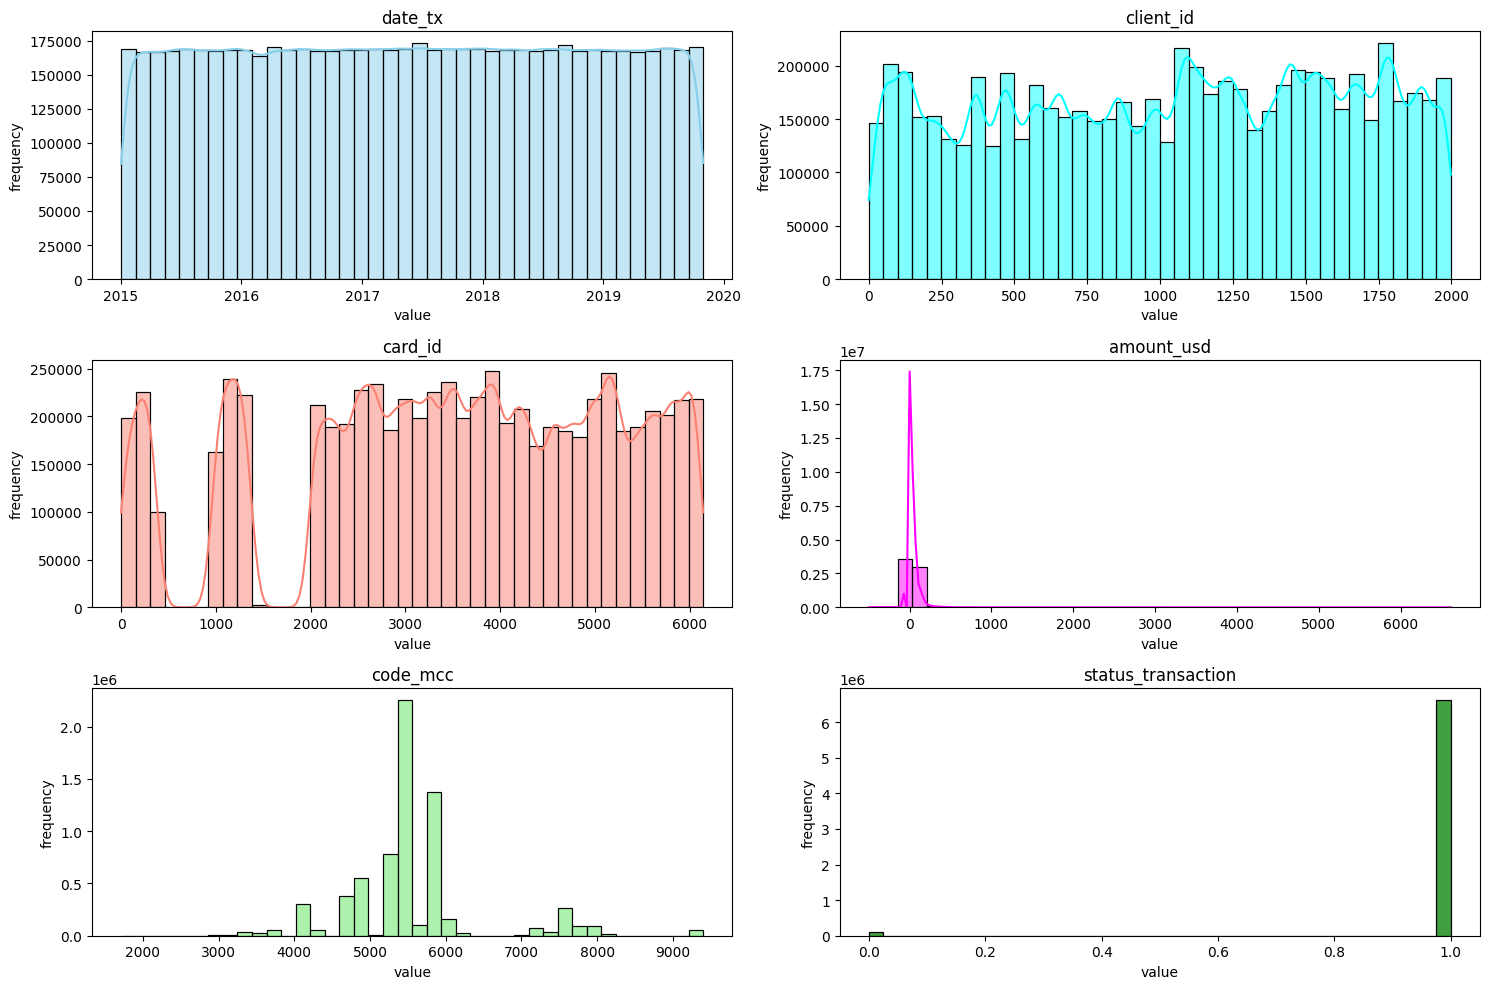

In [186]:
# Configuramos la figura para los histogramas con 3 filas y 2 columnas
fig, axs = plt.subplots(3,2, figsize=(15,10))

# Histograma para columna 'date_tx' (df 'transaction_m')
sns.histplot(data= transaction_m['date_tx'], bins=40, color='skyblue', edgecolor='black', kde=True, ax=axs[0,0])
axs[0,0].set_title('date_tx')
axs[0,0].set_xlabel('value')
axs[0,0].set_ylabel('frequency')

# Histograma para columna 'client_id' (df 'transaction_m')
sns.histplot(data= transaction_m['client_id'], bins=40, color='cyan', edgecolor='black', kde=True, ax=axs[0,1])
axs[0,1].set_title('client_id')
axs[0,1].set_xlabel('value')
axs[0,1].set_ylabel('frequency')

# Histograma para columna 'card_id' (df 'transaction_m')
sns.histplot(data= transaction_m['card_id'], bins=40, color='salmon', edgecolor='black', kde=True, ax=axs[1,0])
axs[1,0].set_title('card_id')
axs[1,0].set_xlabel('value')
axs[1,0].set_ylabel('frequency')

# Histograma para columna 'amount_usd' (df 'transaction_m')
sns.histplot(data= transaction_m['amount_usd'], bins=40, color='magenta', edgecolor='black', kde=True, ax=axs[1,1])
axs[1,1].set_title('amount_usd')
axs[1,1].set_xlabel('value')
axs[1,1].set_ylabel('frequency')

# Histograma para columna 'code_mcc' (df 'transaction_m')
sns.histplot(data= transaction_m['code_mcc'], bins=40, color='lightgreen', edgecolor='black', ax=axs[2,0])
axs[2,0].set_title('code_mcc')
axs[2,0].set_xlabel('value')
axs[2,0].set_ylabel('frequency')

# Histograma para columna 'status_transaction' (df 'transaction_m')
sns.histplot(data= transaction_m['status_transaction'], bins=40, color='green', edgecolor='black', ax=axs[2,1])
axs[2,1].set_title('status_transaction')
axs[2,1].set_xlabel('value')
axs[2,1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

En cuanto a las distribuciones podemos decir que en principio:
* **'date_tx'**, **'client_id'**: Siguen una distribución bastante uniforme.
* **'card_id'**: Se asemeja a una distribución uniforme, aunque hay espacios vacíos.
* **'amount_usd'**: Se asemeja a una distribución sesgada. Será necesario estudiar los outliers. Además, para visualizarlo de mejor manera vamos a establecer rangos de montos y convertirla en variable categórica. Ver apartado 'amount_usd (df 'transaction_m')'.
* **'code_mcc'**: Se representa mejor si hacemos un gráfico de barras, porque si bien aquí es una variable numérica discreta, en realidad responde a una variable cualitativa nominal. Ver apartado 'code_mcc (df 'transaction_m')'.
* **'status_transaction'**: Se representa mejor si hacemos un gráfico de torta, porque si bien aquí es una variable dummy, en realidad responde a una variable cualitativa dicotómica. Ver apartado 'status_transaction (df 'transaction_m')'.

In [183]:
# Construimos gráficos de barras para ver cómo es la distribución de las frecuencias de las variables categóricas

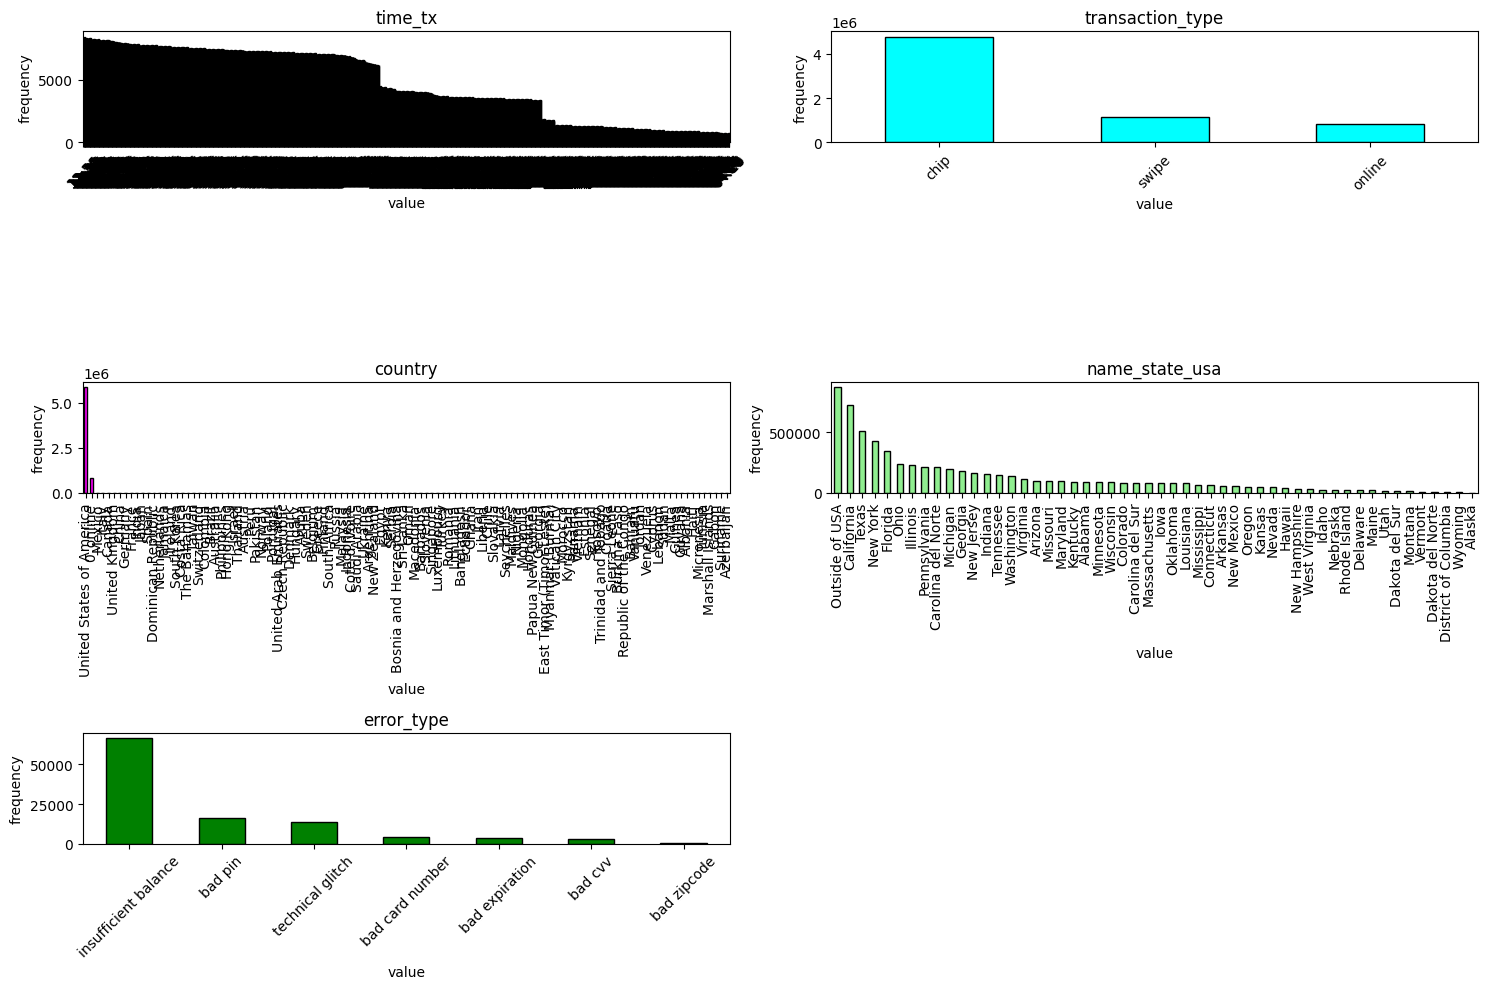

In [187]:
# Configuramos la figura para los gráficos de barras
fig = plt.figure(figsize=(15,10))

# Gráfico de barras para columna 'time_tx' (df 'transaction_m')
plt.subplot(3,2,1)
transaction_m['time_tx'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('time_tx')
plt.xticks(rotation=45)
plt.xlabel('value')
plt.ylabel('frequency')

# Gráfico de barras para columna 'transaction_type' (df 'transaction_m')
plt.subplot(3,2,2)
transaction_m['transaction_type'].value_counts().plot(kind='bar', color='cyan', edgecolor='black')
plt.title('transaction_type')
plt.xticks(rotation=45)
plt.xlabel('value')
plt.ylabel('frequency')

# Gráfico de barras para columna 'country' (df 'transaction_m')
plt.subplot(3,2,3)
transaction_m['country'].value_counts().plot(kind='bar', color='magenta', edgecolor='black')
plt.title('country')
plt.xticks(rotation=90)
plt.xlabel('value')
plt.ylabel('frequency')

# Gráfico de barras para columna 'name_state_usa' (df 'transaction_m')
plt.subplot(3,2,4)
transaction_m['name_state_usa'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('name_state_usa')
plt.xticks(rotation=90)
plt.xlabel('value')
plt.ylabel('frequency')

# Gráfico de barras para columna 'error_type' (df 'error_m')
plt.subplot(3,2,5)
error_m['error_type'].value_counts().plot(kind='bar', color='green', edgecolor='black')
plt.title('error_type')
plt.xticks(rotation=45)
plt.xlabel('value')
plt.ylabel('frequency')

plt.tight_layout()
plt.show()

En cuanto a las distribuciones podemos decir que en principio:
* **'time_tx'**: No hay claridad en la visualización. Para visualizar de mejor manera conviene establecer rangos de tiempo. Ver apartado 'time_tx (df 'transaction_m')'.
* **'transaction_type'**: El tipo de transacción más común es 'chip', el menos común es 'online'.
* **'country'**, **'name_state_usa'**: Están muy dispersos los datos. Para visualizar de mejor manera conviene construir los gráficos por separado. Ver apartado 'country (df 'transaction_m')' y 'name_state_usa' (df 'transaction_m').
* **'error_type'**: El error más común es 'insufficient balance', el menos común es 'bad zipcode'.

* Luego de haber construido los gráficos para ver las distribuciones de las variables, vamos a centrarnos en las variables más significativas y en aquellas que no pudimos visualizar con claridad la distribución por cómo habíamos contruido los gráficos:

### amount_usd (df 'transaction_m')

In [188]:
# Vemos los parámetros estadísticos de la columna 'amount_usd'
transaction_m[['amount_usd']].agg(['mean', 'median', stat.mode, 'std']).round(2)

,amount_usd
mean,42.78
median,28.85
mode,80.00
std,81.17


In [186]:
# Vemos que la mediana < media < moda. 
# La desviación estándar respecto a la media es muy grande.

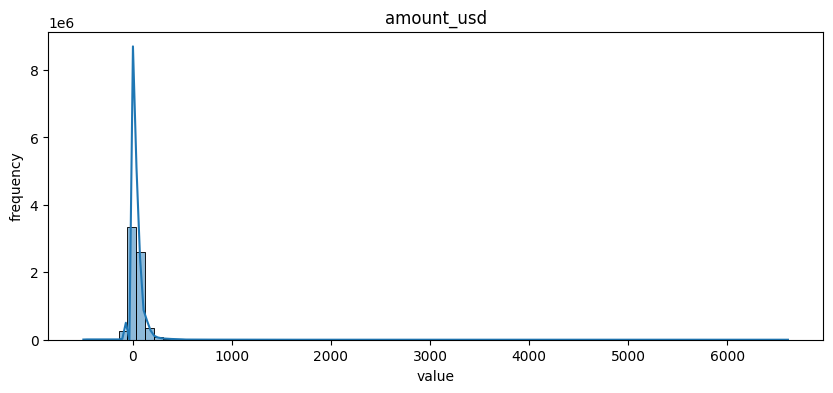

In [189]:
# Histograma para columna 'amount_usd' (df 'transaction_m')
plt.figure(figsize=(10,4))
sns.histplot(data=transaction_m, x='amount_usd', bins=80, edgecolor='black', kde=True)
plt.title('amount_usd')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [190]:
# Los valores empiezan con una frecuencia muy baja por la parte de la izquierda, luego aumenta significativamente, y después 
# disminuye la frecuencia. Tiene una cola muy larga hacia la derecha. Es una distribución sesgada.
# La distribución está muy concentrada entre los valores 0 y 300 aproximadamente. A su vez existen muchos outliers 
# hacia para la derecha, y un poco hacia la izquierda. La variabilidad de importes en dólares es muy grande. 
# los datos están muy dispersos ya que su desviación estándar es muy alta.
# Antes de seguir, es necesario estudiar los outliers.

* Estudio de **outliers**:

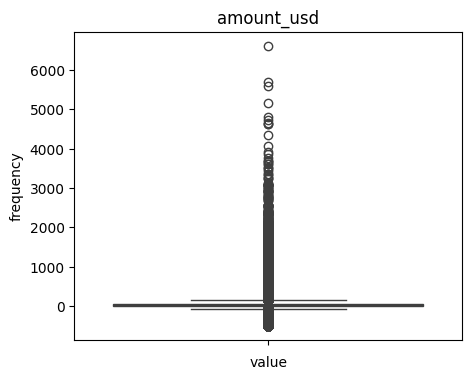

In [191]:
# Creamos un gráfico de caja y bigotes para visualizar los outliers
plt.figure(figsize=(5,4))
sns.boxplot(y=transaction_m['amount_usd'])
plt.title('amount_usd')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [190]:
# Vemos que la dispersión de importes en dólares es muy alta hacia arriba de la mediana, y hay poca variabilidad hacia abajo de la 
# mediana. 
# Se puede apreciar la presencia de bastantes outliers. Estos outliers forman parte de los datos, no son errores, 
# por lo tanto no los vamos a eliminar porque forman parte de la variabiidad natural de los datos.

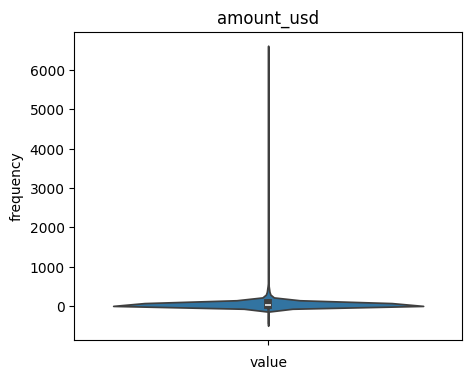

In [192]:
# Creamos un violit plot para no sólo visualizar la distribución, sino para también ver la densidad de los datos.
plt.figure(figsize=(5,4))
sns.violinplot(y=transaction_m['amount_usd'])
plt.title('amount_usd')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [192]:
# Notamos la alta concentración entre el valor 0 y 300, y la enorme variabilidad hacia arriba de la mediana, 
# y poca variabilidad hacia abajo de la mediana, hay más concentración hacia abajo.

In [193]:
# Al ver tanta variabilidad de valores no podemos confiar en la media y en la desviación estándar porque están muy influidos 
# por los valores atípicos.  
# Conviene primero convertir la variable a categórica estableciendo grupos de montos.

In [194]:
# Observamos la variable 'amount_usd'
transaction_m['amount_usd'].value_counts().sort_values(ascending=False)

amount_usd
80.00      65676
100.00     63818
60.00      50852
120.00     40313
40.00      27991
           ...  
652.35         1
1265.67        1
397.54         1
693.96         1
694.30         1
Name: count, Length: 63654, dtype: int64

In [195]:
# Exploramos nuevamente los parámetros estadísticos de la variable 'amount_usd'
transaction_m['amount_usd'].describe().round(2)

count    6734248.00
mean          42.78
std           81.17
min         -500.00
25%            8.91
50%           28.85
75%           63.07
max         6613.44
Name: amount_usd, dtype: float64

In [196]:
# Para armar los grupos de importes en dólares, estableceremos intervalos cada 500 dólares teniendo en cuenta el valor mínimo 
# y el valor máximo
bins= [-500,0,500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000]

In [197]:
# Creamos una nueva columna con los grupos de importes en dólares llamada 'amount_usd_group'
transaction_m['amount_usd_group'] = pd.cut(transaction_m['amount_usd'], bins = bins)

In [198]:
# Visualizamos el dataframe
transaction_m.sample(5)

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa,amount_usd_group
5893683,22722607,2019-03-25,96,361,60.00,43293,92887,5499,16:23,1,chip,Yorba Linda,United States of America,California,"(0, 500]"
915250,16593054,2015-08-30,371,1227,9.37,61195,60640,5541,08:22,1,chip,Chicago,United States of America,Illinois,"(0, 500]"
3988643,20369892,2017-11-12,148,4288,108.12,83659,3222,7922,09:22,1,swipe,Bristol,United States of America,New Hampshire,"(0, 500]"
1453191,17252499,2016-01-18,120,5813,90.48,36934,53132,7538,07:01,1,chip,Franklin,United States of America,Wisconsin,"(0, 500]"
2433394,18456002,2016-10-02,506,4513,72.84,86616,14086,4814,10:02,1,chip,Lancaster,United States of America,New York,"(0, 500]"


In [199]:
# Vemos el tipo de datos de la nueva columna creada
transaction_m['amount_usd_group'].dtypes

CategoricalDtype(categories=[   (-500, 0],     (0, 500],  (500, 1000], (1000, 1500],
                  (1500, 2000], (2000, 2500], (2500, 3000], (3000, 3500],
                  (3500, 4000], (4000, 4500], (4500, 5000], (5000, 5500],
                  (5500, 6000], (6000, 6500], (6500, 7000]],
, ordered=True, categories_dtype=interval[int64, right])

In [200]:
# Exploramos los parámetros estadísticos de la variable 'amount_usd_group'
transaction_m['amount_usd_group'].describe()

count      6734161
unique          14
top       (0, 500]
freq       6377586
Name: amount_usd_group, dtype: object

In [201]:
# Hacemos un recuento de la cantidad de observaciones por grupo de importes en dólares
transaction_m['amount_usd_group'].value_counts().sort_index()

amount_usd_group
(-500, 0]        335110
(0, 500]        6377586
(500, 1000]       16768
(1000, 1500]       3988
(1500, 2000]        561
(2000, 2500]         73
(2500, 3000]         33
(3000, 3500]         21
(3500, 4000]         10
(4000, 4500]          2
(4500, 5000]          5
(5000, 5500]          1
(5500, 6000]          2
(6000, 6500]          0
(6500, 7000]          1
Name: count, dtype: int64

In [202]:
# La frecuencia la transformamos a porcentaje
transaction_m['amount_usd_group'].value_counts(normalize=True).sort_index().round(4) * 100

amount_usd_group
(-500, 0]        4.98
(0, 500]        94.70
(500, 1000]      0.25
(1000, 1500]     0.06
(1500, 2000]     0.01
(2000, 2500]     0.00
(2500, 3000]     0.00
(3000, 3500]     0.00
(3500, 4000]     0.00
(4000, 4500]     0.00
(4500, 5000]     0.00
(5000, 5500]     0.00
(5500, 6000]     0.00
(6000, 6500]     0.00
(6500, 7000]     0.00
Name: proportion, dtype: float64

In [203]:
# Vemos la alta concentración de valores en el rango 0 a 500, representa un 94,70%.

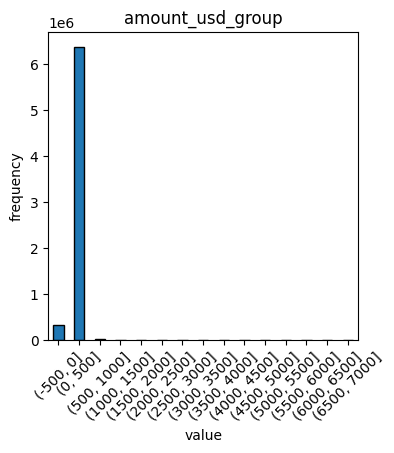

In [204]:
# Hacemos un gráfico de barras de la variable 'amount_usd_group'
plt.figure(figsize=(4,4))
transaction_m['amount_usd_group'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('amount_usd_group')
plt.xticks(rotation=45)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

In [205]:
# Al ver la alta concentración de observaciones en el rango (0, 500], y seguido del rango (-500, 0], los parámetros estadísticos 
# tienen sentido analizarlos entre esos valores, ya que en conjunto representan:

In [205]:
round(len(transaction_m[transaction_m['amount_usd'] <= 500]) / len(transaction_m)*100,2)

99.68

In [207]:
# Representan un 99,68% de las observaciones.

In [206]:
# Guardamos un nuevo dataframe filtrado por los importes en dólares <= 500 dólares
transaction_m_menos_500 = transaction_m[transaction_m['amount_usd'] <= 500]

In [207]:
# Exploramos los parámetros estadísticos de los importes en dólares <= 500 dólares
transaction_m_menos_500['amount_usd'].describe().round(2)

count    6712783.00
mean          40.28
std           65.66
min         -500.00
25%            8.86
50%           28.68
75%           62.68
max          500.00
Name: amount_usd, dtype: float64

In [208]:
# Vemos los parámetros estadísticos: media, mediana, moda y desviación estándar
transaction_m_menos_500[['amount_usd']].agg(['mean', 'median', stat.mode, 'std']).round(2)

,amount_usd
mean,40.28
median,28.68
mode,80.00
std,65.66


In [210]:
# Vemos que la mediana < media < moda. 
# La desviación estándar respecto a la media es muy grande.
# Es decir, son las mismas conclusiones que obtuvimos cuando tomamos todos los datos.

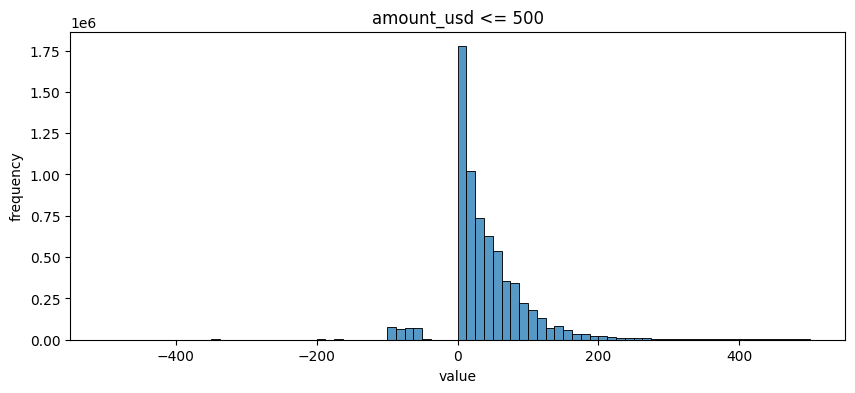

In [211]:
# Histograma para columna 'amount_usd' <= 500 (df 'transaction_m')
plt.figure(figsize=(10,4))
sns.histplot(data=transaction_m_menos_500, x='amount_usd', bins=80, edgecolor='black')
plt.title('amount_usd <= 500')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

* Conclusión:

De esta manera vemos más claros los datos: Existe una alta concentración de los valores entre 0 y 100 dólares, los valores se dispersan mucho hacia la derecha, y un poco hacia la izquierda.

Se puede apreciar la presencia de bastantes outliers. Estos outliers forman parte de los datos. No son errores.

La variable sigue una distribución sesgada.

### code_mcc (df 'transaction_m')

In [212]:
# Observamos la frecuencia de la variable 'code_mcc' 
transaction_m['code_mcc'].value_counts().sort_values(ascending=False)

code_mcc
5411    805218
5499    736533
5541    714599
5812    506299
5912    388874
         ...  
3006       182
3144       181
3075       165
5722       160
5733       153
Name: count, Length: 109, dtype: int64

In [213]:
# La frecuencia la transformamos a porcentaje
transaction_m['code_mcc'].value_counts(normalize=True).round(4) * 100

code_mcc
5411    11.96
5499    10.94
5541    10.61
5812     7.52
5912     5.77
        ...  
3006     0.00
3144     0.00
3075     0.00
5722     0.00
5733     0.00
Name: proportion, Length: 109, dtype: float64

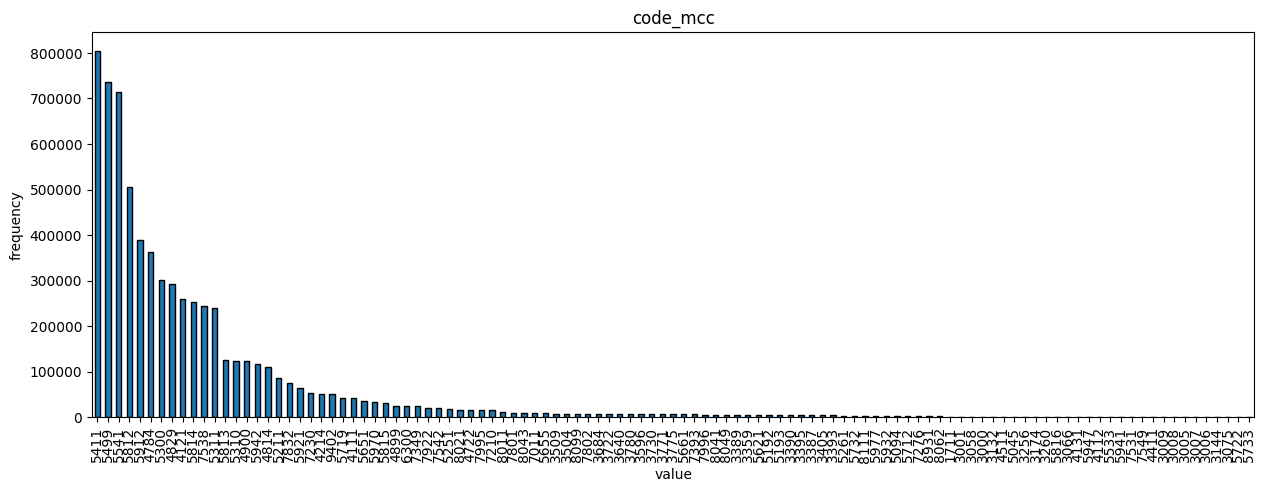

In [214]:
# Con gráfico de barras visualizamos la frecuencia de la variable 'code_mcc' 
plt.figure(figsize=(15,5))
transaction_m['code_mcc'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('code_mcc')
plt.xticks(rotation=90)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

* Conclusión: 

La mayor cantidad de transacciones corresponden a estos rubros de gastos:
 - 5411: Supermercados
 - 5499: Tiendas de alimentos diversos
 - 5541: Estaciones de servicio
 - 5812: Restaurantes
 - 5912: Farmacias

Existen pocos rubros de comercios donde los clientes realizan más transacciones, luego hay muchos rubros con pocas transacciones. 
Están muy dispersos los gastos en relación a los conceptos de gasto.

### status_transaction (df 'transaction_m')

In [215]:
# Observamos la frecuencia de la variable 'status_transaction' 
frec_status_trans = transaction_m['status_transaction'].value_counts().rename(index={1:'successful', 0:'failed'})
frec_status_trans

status_transaction
successful    6626747
failed         107501
Name: count, dtype: int64

In [216]:
# La frecuencia la transformamos a porcentaje
transaction_m['status_transaction'].value_counts(normalize=True).round(4) * 100

status_transaction
1    98.4
0     1.6
Name: proportion, dtype: float64

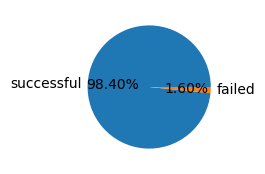

In [217]:
# Con un gráfico de torta para representamos la proporción de los estados de transacciones
plt.figure(figsize=(3,2))
plt.pie(frec_status_trans, labels= frec_status_trans.index[:], autopct='%1.2f%%')
plt.show()

* Conclusión:

Más de un 98% de la muestra fueron transacciones exitosas. Menos del 2% tuvieron errores.

### time_tx (df 'transaction_m')

In [218]:
# Consultamos el tipo de dato de esta columna
transaction_m['time_tx'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [219]:
# Visualizamos la frecuencia
transaction_m['time_tx'].value_counts()

time_tx
12:36    8486
12:51    8446
12:34    8437
12:39    8433
12:30    8428
         ... 
04:03     739
04:29     738
04:26     723
04:00     716
04:15     708
Name: count, Length: 1440, dtype: int64

In [220]:
# Exploramos los parámetros estadísticos de la variable 'time_tx'
transaction_m['time_tx'].describe()

count     6734248
unique       1440
top         12:36
freq         8486
Name: time_tx, dtype: object

In [221]:
# Para visualizar esta variable de mejor manera llamamos a la función 'categorize_time' que establece rangos de tiempo.
# Aplicamos la función a la columna 'time' y creamos una nueva columna con los rangos llamada 'time_category'
transaction_m['time_category'] = transaction_m['time_tx'].apply(categorize_time)

In [222]:
# Corroboramos que los rangos de tiempo estén correctos
transaction_m[transaction_m['time_category'] == 'night']

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,country,name_state_usa,amount_usd_group,time_category
3532,15475544,2015-01-01,1238,1195,95.17,35451,22204,5812,20:00,1,chip,Arlington,United States of America,Virginia,"(0, 500]",night
3533,15475546,2015-01-01,1398,4930,14.55,75936,7054,5814,20:00,1,chip,Parsippany,United States of America,New Jersey,"(0, 500]",night
3534,15475547,2015-01-01,145,5521,-51.00,43293,37710,5499,20:01,1,chip,Briceville,United States of America,Tennessee,"(-500, 0]",night
3535,15475548,2015-01-01,328,3150,80.00,27092,28215,4829,20:01,1,swipe,Charlotte,United States of America,Carolina del Norte,"(0, 500]",night
3536,15475549,2015-01-01,490,5133,76.31,61195,78230,5541,20:01,1,chip,San Antonio,United States of America,Texas,"(0, 500]",night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6734243,23761868,2019-10-31,1718,2379,1.11,86438,91792,5499,23:56,1,chip,West Covina,United States of America,California,"(0, 500]",night
6734244,23761869,2019-10-31,1766,2066,12.80,39261,0,5815,23:56,1,online,0_online,0_online,Outside of USA,"(0, 500]",night
6734245,23761870,2019-10-31,199,1031,40.44,2925,75002,4900,23:57,1,swipe,Allen,United States of America,Texas,"(0, 500]",night
6734246,23761873,2019-10-31,1986,5443,4.00,46284,94014,5411,23:58,1,chip,Daly City,United States of America,California,"(0, 500]",night


In [223]:
# Consultamos el tipo de dato de la variable 'time_category'
transaction_m['time_category'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [224]:
# Transformamos el tipo de dato a variable categórica ordinal para que las categorías nos queden ordenadas y se visualicen 
# en orden. Para ello primero vemos las categorías únicas
transaction_m['time_category'].unique()

<StringArray>
['after midnight', 'early morning', 'morning', 'afternoon', 'evening',
 'night']
Length: 6, dtype: str

In [225]:
# Luego transformamos el tipo de dato a 'categorical'
transaction_m['time_category'] = pd.Categorical(transaction_m['time_category'], categories = ['after midnight', 'early morning', 'morning', 'afternoon', 'evening', 'night'], ordered=True)

In [226]:
# Observamos la frecuencia de la variable 'time_category' 
transaction_m['time_category'].value_counts().sort_index()

time_category
after midnight     238485
early morning      995186
morning           1811519
afternoon         1818317
evening           1149275
night              721466
Name: count, dtype: int64

In [227]:
# La frecuencia la transformamos a porcentaje
transaction_m['time_category'].value_counts(normalize=True).sort_index().round(4) * 100

time_category
after midnight     3.54
early morning     14.78
morning           26.90
afternoon         27.00
evening           17.07
night             10.71
Name: proportion, dtype: float64

In [228]:
# Exploramos los parámetros estadísticos de la variable 'time_category'
transaction_m['time_category'].describe()

count       6734248
unique            6
top       afternoon
freq        1818317
Name: time_category, dtype: object

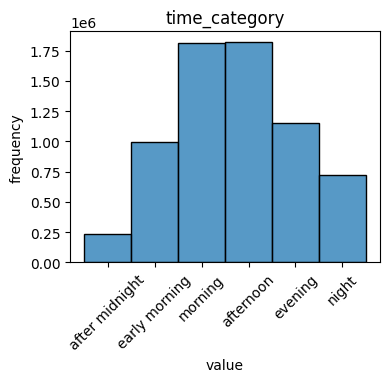

In [229]:
# Con un histograma visualizamos la frecuencia de la variable 'time_category' 
plt.figure(figsize=(4,3))
sns.histplot(data=transaction_m, x ='time_category')
plt.title('time_category')
plt.xticks(rotation=45)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

* Conclusión:

La mayor cantidad de transacciones se realizaron por la tarde, seguido por la mañana. Durante la madrugada se registraron la menor cantidad de transacciones.

### country (df 'transaction_m')

In [230]:
# Observamos la frecuencia de la variable 'country' 
transaction_m['country'].value_counts().sort_values(ascending=False)

country
United States of America    5864042
0_online                     823412
Mexico                        13063
Italy                          5940
Canada                         5731
                             ...   
Tunisia                           4
Marshall Islands                  4
Gabon                             3
Suriname                          3
Azerbaijan                        2
Name: count, Length: 114, dtype: int64

In [231]:
# La frecuencia la transformamos a porcentaje
transaction_m['country'].value_counts(normalize=True).round(4) * 100

country
United States of America    87.08
0_online                    12.23
Mexico                       0.19
Italy                        0.09
Canada                       0.09
                            ...  
Tunisia                      0.00
Marshall Islands             0.00
Gabon                        0.00
Suriname                     0.00
Azerbaijan                   0.00
Name: proportion, Length: 114, dtype: float64

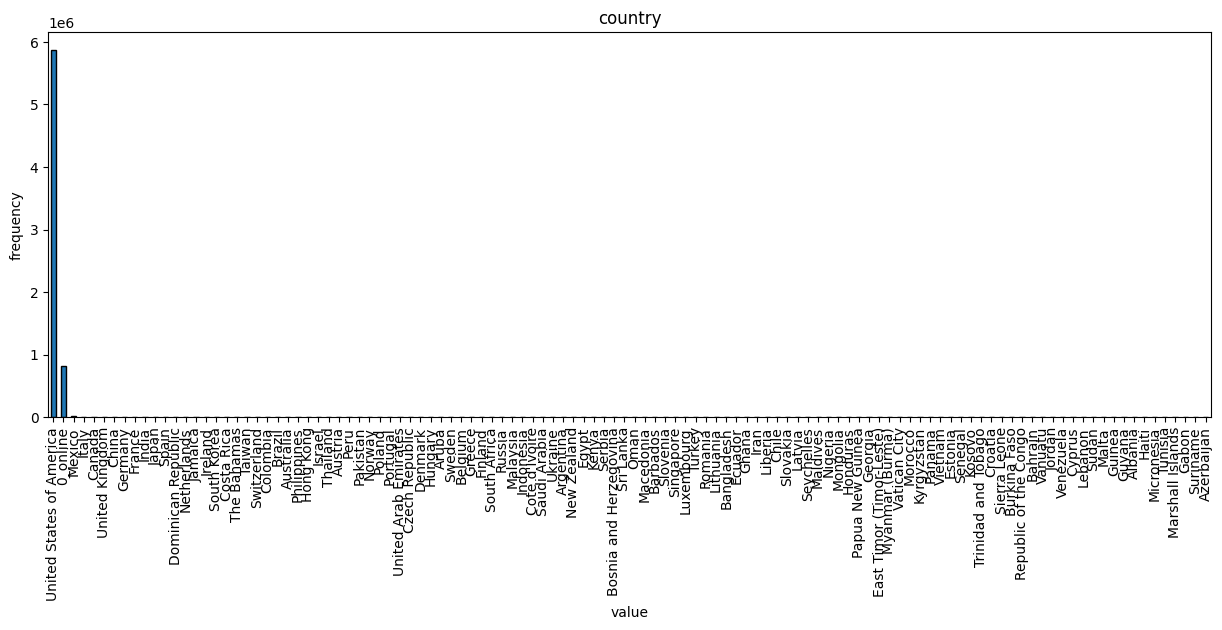

In [232]:
# Con gráfico de barras visualizamos la frecuencia de la variable 'country' 
plt.figure(figsize=(15,5))
transaction_m['country'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('country')
plt.xticks(rotation=90)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

* Conclusión:

Observamos la concentración de transacciones en comercios en el país USA mayormente (87,08%), seguido por transacciones efectuadas en forma online (12,23%).

### name_state_usa (df 'transaction_m')

In [233]:
# Observamos la frecuencia de la variable 'name_state_usa' 
transaction_m['name_state_usa'].value_counts().sort_values(ascending=False)

name_state_usa
Outside of USA          870206
California              726257
Texas                   507276
New York                430160
Florida                 349872
Ohio                    242747
Illinois                230605
Pennsylvania            213634
Carolina del Norte      212784
Michigan                200262
Georgia                 185071
New Jersey              161956
Indiana                 152776
Tennessee               145109
Washington              141356
Virginia                114844
Arizona                  97795
Missouri                 97617
Maryland                 97548
Kentucky                 89717
Alabama                  88779
Minnesota                88474
Wisconsin                87566
Colorado                 85492
Carolina del Sur         85414
Massachusetts            84999
Iowa                     84312
Oklahoma                 81227
Louisiana                79263
Mississippi              68563
Connecticut              67866
Arkansas                

In [234]:
# La frecuencia la transformamos a porcentaje
transaction_m['name_state_usa'].value_counts(normalize=True).round(4) * 100

name_state_usa
Outside of USA          12.92
California              10.78
Texas                    7.53
New York                 6.39
Florida                  5.20
Ohio                     3.60
Illinois                 3.42
Pennsylvania             3.17
Carolina del Norte       3.16
Michigan                 2.97
Georgia                  2.75
New Jersey               2.40
Indiana                  2.27
Tennessee                2.15
Washington               2.10
Virginia                 1.71
Arizona                  1.45
Missouri                 1.45
Maryland                 1.45
Kentucky                 1.33
Alabama                  1.32
Minnesota                1.31
Wisconsin                1.30
Colorado                 1.27
Carolina del Sur         1.27
Massachusetts            1.26
Iowa                     1.25
Oklahoma                 1.21
Louisiana                1.18
Mississippi              1.02
Connecticut              1.01
Arkansas                 0.88
New Mexico               

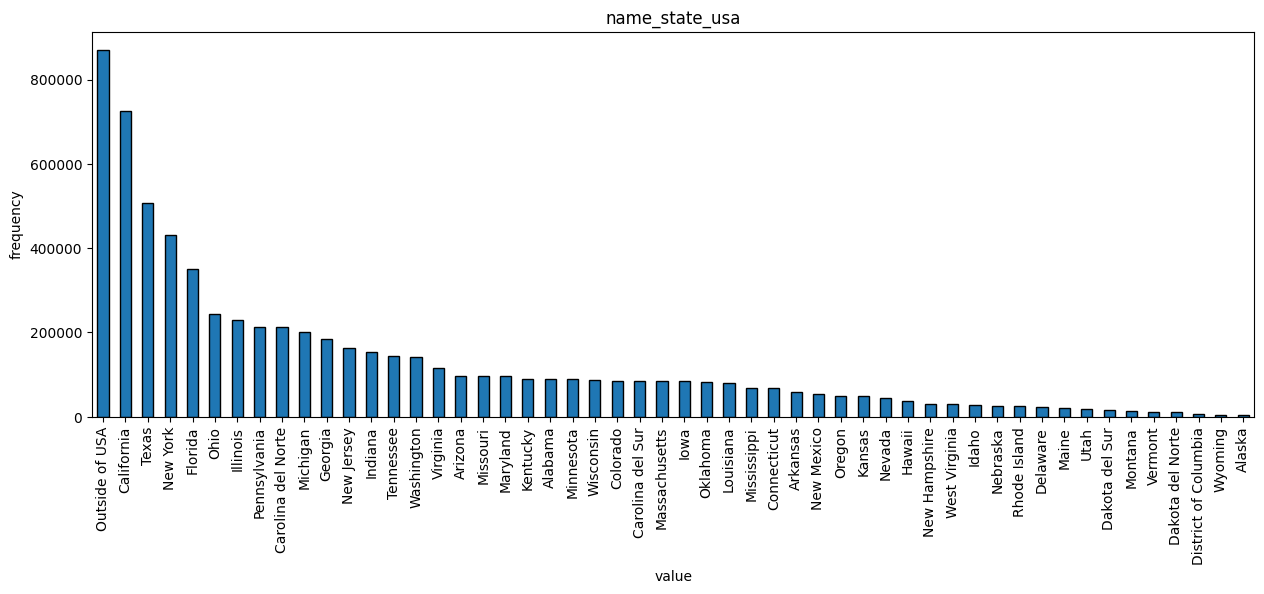

In [235]:
# Con gráfico de barras visualizamos la frecuencia de la variable 'name_state_usa' 
plt.figure(figsize=(15,5))
transaction_m['name_state_usa'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('name_state_usa')
plt.xticks(rotation=90)
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

* Conclusión:

La mayor parte de las transacciones se realizan en forma online ('Outside of USA', que representa un 12,92%, se compone de 'online' y 'fuera del país USA'), seguido por transacciones efectuadas en los siguientes estados de USA: California, Texas, Nueva York, Florida, Ohio, Illinois, Pennsylvania, y Carolina del Norte. Estos 8 estados en su conjunto sumarizan 43,25%.

In [239]:
# Dentro de 'Outside of USA' encontramos transacciones online y en comercios fuera de USA
transaction_m[transaction_m['name_state_usa'] == 'Outside of USA'].groupby('country').count()

,id_transaction,date_tx,client_id,card_id,amount_usd,merchant_id,zip_code,code_mcc,time_tx,status_transaction,transaction_type,city,name_state_usa,amount_usd_group,time_category
country,,,,,,,,,,,,,,,
0_online,823412,823412,823412,823412,823412,823412,823412,823412,823412,823412,823412,823412,823412,823399,823412
Albania,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Argentina,64,64,64,64,64,64,64,64,64,64,64,64,64,64,64
Aruba,161,161,161,161,161,161,161,161,161,161,161,161,161,161,161
Australia,344,344,344,344,344,344,344,344,344,344,344,344,344,344,344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
United Kingdom,2299,2299,2299,2299,2299,2299,2299,2299,2299,2299,2299,2299,2299,2299,2299
Vanuatu,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
Vatican City,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15


De las 870.206 transacciones que componen 'Outside of USA' (12,92%), 823.412 corresponden a transacciones online (representando un 94,62%). El resto corresponde a transacciones hechas afuera del país USA.

## Tablas limpias a conectar con MySQL Workbench y a exportar a formato .csv

* Exploramos la información general de los dataframes a conectar con MySQL Workbench y a exportar en formato .csv

In [240]:
dataframe_list = [transactions, transaction_type, city, country, state_usa, error_type, transactions_error_type]
dataframe_name = ['transactions', 'transaction_type', 'city', 'country', 'state_usa', 'error_type', 'transactions_error_type']

for i, df in enumerate(dataframe_list):
    print('\n', f'dataframe ** {dataframe_name[i]} **:')
    print(df.info(show_counts=True), '\n')


 dataframe ** transactions **:
<class 'pandas.DataFrame'>
RangeIndex: 6734248 entries, 6571667 to 13305914
Data columns (total 16 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id_transaction       6734248 non-null  int64         
 1   date_tx              6734248 non-null  datetime64[us]
 2   client_id            6734248 non-null  int64         
 3   card_id              6734248 non-null  int64         
 4   amount_usd           6734248 non-null  float64       
 5   merchant_id          6734248 non-null  int64         
 6   zip_code             6734248 non-null  int64         
 7   code_mcc             6734248 non-null  int64         
 8   time_tx              6734248 non-null  str           
 9   calendar_id          6734248 non-null  int64         
 10  time_id              6734248 non-null  str           
 11  transaction_type_id  6734248 non-null  int64         
 12  city_id              6734248

* Cambiamos el directorio de trabajo a 'FILES_DIRECTORY' porque allí exportaremos las tablas 'limpias' en formato .csv

In [381]:
os.chdir(FILES_DIRECTORY)

In [382]:
# Chequeamos el directorio actual de trabajo

In [383]:
pwd!

'C:\\Users\\germa\\Documents\\Python\\edicion_12.0\\Proyecto_integrador\\ETL_finales\\files'

* Exportamos de las tablas 'limpias' a formato .csv

In [384]:
transactions.to_csv('transactions.csv', index=False)
transaction_type.to_csv('transaction_type.csv', index=False)
error_type.to_csv('error_type.csv', index=False)
transactions_error_type.to_csv('transactions_error_type.csv', index=False)

In [244]:
transactions.to_csv('transactions.csv', index=False)
transaction_type.to_csv('transaction_type.csv', index=False)
city.to_csv('city_draft.csv', index=False)
country.to_csv('country_draft.csv', index=False)
state_usa.to_csv('state_usa_draft.csv', index=False)
error_type.to_csv('error_type.csv', index=False)
transactions_error_type.to_csv('transactions_error_type.csv', index=False)

* **Aclaración importante**: La tabla 'users' se va a relacionar con los **dataframes: 'city', 'country', 'state_usa'**. Por lo tanto,  dichos dataframes se seguirán analizando en el script de Python llamado **ETL tabla 'users'** hasta obtener los archivos .csv limpios definitivos.